# ROMS River Forcing File  
The purpose of this script it to find the rivers in the Beaufort Sea shelf grid, then load in and format river data for each river, and write all of that information to a river forcing file. 


For the Alaskan Beaufort Sea shelf, there are the following rivers that should be accounted for in the model if possible (pulled from https://www.openstreetmap.org/search?whereami=1&query=69.62926%2C-141.26456#map=13/69.6293/-141.2646): 
    
    - Kalikpik River (70.4442, -151.9452), 17.6 m
    - Tingmeachsiovik River (70.4096, -151.3608), 9 m
    - Fish Creek (70.3786, -151.3608), 405.9 m
    - Colville River (70.4517, -150.3589), 3500 m
    - Sakonowyak River (70.4452, -149.0206), 733.3 m
    - Kuparik River (splits into two rivers near coast):
        - Kukpuk River (70.4152, -148.8956), 530 m 
        - Kuparuk River (70.3924, -148.8393), 300 m
    - Fawn Creek (70.4099, -148.7271), 300 m
    - Putuligayuk River (70.3113, -148.4792), 409 m
    - Sagavanirktok River (70.2924, -148.1712), 2000 m 
    - Shaviovik River (70.1803, -147.2856), 5 m
    - Canning River (splits into two neat coast):  
        - Staines River (70.1419, -145.9989), 892.9 m
        - Canning River (70.061, -145.5553), 1070 m
    - Katakturuk River (splits into two near coast but keeps the same name):  
        - (69.9814, -145.0489), 4.5 m
        - (69.976, -144.9958), 265 m
    - Marsh Creek (69.9787, -144.7938), 4.5 m
    - Carter Creek (69.9671, -144.7036), 9 m
    - Sadlerochit River (70.0226, -144.4347), 17.6 m
    - Hulahula River (70.0654, -144.085), 790 m
    - Okpilak River (70.0483, -143.9978), 35 m
    - (no name) (), (across from Barter Island)  
    - Jago River (70.1088, -143.2918), 921 m
    - Niguanak River (70.058, -142.997), 4.6 m
    - Siksik River (69.9501, -142.4938), 176.5 m
    - Sikrelurak River (69.9343, -142.4455), 17.6 m
    - Angun River (69.9326, -142.4147), 17.6 m
    - Kogotpak River (69.8621, -142.2647), 17.6 m
    - Ailchilik River (69.8442, -142.1021), 35.3 m
    - Egaksrak River (69.8181, -142.044), 17.6 m
    - Kongakut River (69.7858, -141.7429), 70.6 m
    - (no name) (69.6501, -141.4161), 17.6 m
    - Turner River (69.6404, -141.3945), 17.6 m 
    - (no name) (69.6259, -141.3565), 35.3 m
    - (no name) (69.62926, -141.26456), 4.6 m

    
Our first approach will be to pull this data from the Feng et al. 2021 RADR dataset. Before loading in any river discahrge data, let's use the coordinates above to find where these rivers are in the grid.

Notes:
- Be sure to specify where the rivers are on the grid in terms of u and v points, NOT rho points 
- Order of rivers in positional indices is based on order they appear in this notebook, NOT the order of the rivers geographically/above 
- In all of the plots, land is blue and ocean is green
- From conversations with Marisa Repasch, it seems like (at least the Canning River) only has suspended mud and not suspended sand. Suspended sand concentrations will be set to zero and mud will be set to half of the total sediment discharge (so both mud classes are equally represented in riverine sediment).
- <font color='purple'> **River discharge values are pulled from Dylan Blaskey's 2024 river discharge and temperature hindcast data. Additionally, the Putuligayuk, Sakonowyak, and Siksik Rivers have been removed since they are so small. The rating curve for the Sagavanirktok River DSS3 location is used. </font>**
- **This script has been updated to have the same sand sediment classes in all sections of the seabed (and 0 in all rivers), the same unaggregated mud (mud01) in all rivers and all sections of the seabed, and a different aggregated mud in all rivers and sections of the seabed.**


In [1]:
# Load in the packages
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from cftime import num2date, date2num

In [2]:
# Load in the model grid
grid = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj/Model_Inputs/Grids/KakAKgrd_shelf_big010_smooth006.nc')

In [3]:
# Read in/set some grid dimensions 
# Number of vertical layers
s_rho_len = 20

# Number of river cells 
# ***CHECK THIS***
len_river_cells = 17 # made Kuparik one river with one cell # will need to know total up here

In [4]:
# Make a time series to use that matches the time/frequency of the RADR data
# (daily from 1 July 2020 - 2 November 2020)
# Do daily for the period of the model run
time = np.arange(pd.datetime(2020,7,1,1,0,0), pd.datetime(2020,11,3,1,0,0), timedelta(days=1))
time = pd.to_datetime(time)
#print(time)

# Conver this to seconds since 2000-01-01 00:00:00
time_tmp = ((time[:] - datetime(1999,12,31)).total_seconds() - 86400)
#print(time_tmp[-1])

# Find the length 
time_tmp_len = len(time_tmp)
print(time_tmp_len)

125


/var/folders/hb/5f7j400j20j7tz7b15m1ysmh0000gn/T/ipykernel_39074/3024506230.py:4: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  time = np.arange(pd.datetime(2020,7,1,1,0,0), pd.datetime(2020,11,3,1,0,0), timedelta(days=1))


In [5]:
# Calculate river_Vshape beforehand
# This is the fraction of river discharge to put in each vertical cell
# and it should be weighted by the thickness of the cell instead of evenly
# distributed because this may (and did most likely) cause momentum to blow up

# Load in previous model output to read in the thicnkesses
# or ROMS_hplus_zeta if it is in there
model_out = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2020/Model_Inputs/Forcing_files/Final_bryclm_conds/Attempt001/ROMS_grid_depth_hpluszeta_2020_003.nc')

# Read in the cell thickness from previous model output (s_rho, eta_rho, xi_rho)
# Use thicknesses from time 0
# First read in z_w
z_w = model_out.z_w[0,:,:,:].values

# Use z_w to get cell thickness
#cell_thick = abs(z_w[1:,:,:]) - abs(z_w[0:-1,:,:])
cell_thick = z_w[1:,:,:] - z_w[0:-1,:,:]

# Check this
print(len(cell_thick[:,200,200]))
print(cell_thick[:,200,200])
print(z_w[1,200,200])
print(z_w[0,200,200])
print(z_w[1,200,200] - z_w[0,200,200])
#print(abs(z_w[1,200,200]) - abs(z_w[0,200,200]))
                            
# Add up the cell thicknesses (eta_rho, xi_rho)
total_thick = np.sum(cell_thick, axis=0)
print(np.shape(total_thick))
                            
# Divide each layer by the total thickness to get the fraction (s_rho, eta_rho, xi_rho)
vshape_all = cell_thick/total_thick

# Is this uniform over the whole grid? If not, need to pull out each location for each river 
print(vshape_all[0,:,:])
#print(vshape_all[10,:,:])
#print(vshape_all[19,:,:])

# No, this is not uniform over space so will need to pull it out for each river

# Check that this adds up to 1
print(np.sum(vshape_all[:,200,200]))
print(np.sum(vshape_all[:,100,150]))
print(np.sum(vshape_all[:,200,80]))

# close enough I hope? They all round to 1

# Print the shape 
print(np.shape(vshape_all))

# Delete this file for memory sake
del(model_out)

20
[65.70848206 72.82378041 70.92791884 67.19657475 62.9259451  58.65596113
 54.74471184 51.51542573 49.26936157 48.23582632 48.50427865 49.98195442
 52.40366954 55.38627721 58.4901931  61.2419827  63.07570574 63.12322434
 59.55679155 44.61849141]
-1092.9880660439737
-1158.696548103701
65.7084820597272
(206, 608)
[[0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 [0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 [0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 ...
 [0.05622787 0.05622878 0.05623429 ... 0.05673282 0.05673214 0.05673163]
 [0.05623551 0.05622717 0.0562304  ... 0.05673321 0.05673262 0.05673212]
 [0.0562343  0.05623307 0.05624342 ... 0.05673341 0.0567331  0.05673245]]
0.9999999999999998
1.0000000000000002
1.0
(20, 206, 608)


In [6]:
# Read in and prime Blaskey river data
# Load in the river data 
river_data_can = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Canning_River.csv')
river_data_col = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Colville_River.csv')
river_data_fis = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Fish_Creek.csv')
river_data_hul = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Hulahula_River.csv')
river_data_jag = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Jago_River.csv')
river_data_kal = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Kalikpik_River.csv')
river_data_kat = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Katakturuk_River.csv')
river_data_kup = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Kuparik_River.csv')
river_data_sag = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Sagavanirktok_River.csv')
river_data_sta = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/Blaskey_etal_2024_data/Staines_River.csv')


In [7]:
# Add Datetime to Blaskey data (might not be needed for this notebook)
# Prep things for plotting 
# Make datetime to use for plotting
river_data_can['Datetime'] = pd.to_datetime(river_data_can.Date)
river_data_col['Datetime'] = pd.to_datetime(river_data_col.Date)
river_data_fis['Datetime'] = pd.to_datetime(river_data_fis.Date)
river_data_hul['Datetime'] = pd.to_datetime(river_data_hul.Date)
river_data_jag['Datetime'] = pd.to_datetime(river_data_jag.Date)
river_data_kal['Datetime'] = pd.to_datetime(river_data_kal.Date)
river_data_kat['Datetime'] = pd.to_datetime(river_data_kat.Date)
river_data_kup['Datetime'] = pd.to_datetime(river_data_kup.Date)
river_data_sag['Datetime'] = pd.to_datetime(river_data_sag.Date)
river_data_sta['Datetime'] = pd.to_datetime(river_data_sta.Date)

In [8]:
# Set up the equation to use to calculate river sediment load
# Make a function to calculate river suspended sediment load 
# based on river discharge. This is currently set up to use 
# the equation for the Anaktuvuk basin from Lamb and Toniolo 2016.

def calc_river_ssc_Anaktuvuk(Q):
    """
    This function takes river water discharge and
    calculates river suspended sediment load based
    on this discharge. The function is taken from
    equation D-2 of Gary Simoes 2008 'Appendix D: 
    Estimating Sediment Discharge'.
    
    The a and b values in the equation are 
    experimentally determined. For this function,
    the values are taken from the equation for 
    the Anaktuvuk River from Lamb and Toniolo 2016.
    
    Input(s)
    - Q = River water discharge (m3/s)
    
    Output(s)
    - ssc_tmp = suspended sediment discharge ()
    
    # Define some constants 
    # a = the intercept (from a log fit, see Gray Simoes)
    # b = the slope (from a log fit, see Gray Simoes)
    """
    # Define a and b from Lamb and Toniolo 2016
    a = 0.0199 # Change to Chandler
    b = 1.4811 # Change to Chandler
    
    # Calculate the river suspended sediment concentration
    ssc_tmp = a*((Q)**b)
    
    return(ssc_tmp)

In [9]:
# Set up the equation to use to calculate river sediment load
# Make a function to calculate river suspended sediment load 
# based on river discharge. This is set up to use 
# the equation for the Sagavanirktok River from Toniolo et al.
# 2024, specifically site DSS3.

def calc_river_ssc_Sag_DSS3(Q):
    """
    This function takes river water discharge and
    calculates river suspended sediment load based
    on this discharge. The function is taken from
    Figure 2.12 of Toniolo et al. 2024 for site DSS3.
    
    Input(s)
    - Q = River water discharge (m3/s)
    
    Output(s)
    - ssc_tmp = suspended sediment discharge ()
    
    # Define some constants 
    # a = the intercept (from a log fit, see Gray Simoes) (maybe?)
    # b = the slope (from a log fit, see Gray Simoes) (maybe?)
    """
    # Define a and b from Toniolo et al. 2024
    a = 3e-6 # Change to Chandler
    b = 3.0257 # Change to Chandler
    
    # Calculate the river suspended sediment concentration
    ssc_tmp = a*((Q)**b)
    
    return(ssc_tmp)

In [10]:
# Set up the equation to use to calculate river sediment load
# Make a function to calculate river suspended sediment load 
# based on river discharge. This is set up to use 
# the equation for the Sagavanirktok River from Toniolo et al.
# 2024, specifically site DSS2.

def calc_river_ssc_Sag_DSS2(Q):
    """
    This function takes river water discharge and
    calculates river suspended sediment load based
    on this discharge. The function is taken from
    Figure 2.12 of Toniolo et al. 2024 for site DSS2.
    
    Input(s)
    - Q = River water discharge (m3/s)
    
    Output(s)
    - ssc_tmp = suspended sediment discharge ()
    
    # Define some constants 
    # a = the intercept (from a log fit, see Gray Simoes) (maybe?)
    # b = the slope (from a log fit, see Gray Simoes) (maybe?)
    """
    # Define a and b from Toniolo et al. 2024
    a = 1e-5 # Change to Chandler
    b = 2.5255 # Change to Chandler
    
    # Calculate the river suspended sediment concentration
    ssc_tmp = a*((Q)**b)
    
    return(ssc_tmp)

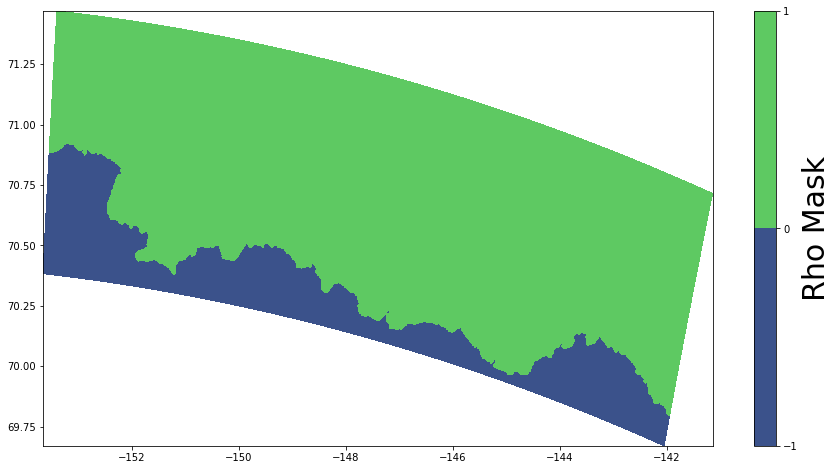

In [11]:
# Plot the grid with the mask to see what we're working with 
fig1, ax1 = plt.subplots(figsize=(15,8))
lev1 = np.arange(-1,2,1)
cs1 = ax1.contourf(grid.lon_rho.values, grid.lat_rho.values, grid.mask_rho.values, lev1)
cbar1 = plt.colorbar(cs1).set_label('Rho Mask', size=30)

In [12]:
# Make lists/arrays to hold the indices for the rivers 
# River identification number (ex: 1 = Kalikpik, 2 = T...)
#riv_id_list = []
riv_id_arr = np.empty((len_river_cells))

# Coordinates of river cells (all of them I think?)
#eta_riv_list = []
#xi_riv_list = []
eta_riv_arr = np.empty((len_river_cells))
xi_riv_arr = np.empty((len_river_cells))

# River transport for each river cell (same size and order as above is the goal)
#riv_transport_list = []
riv_transport_arr = np.empty((time_tmp_len, len_river_cells))

# River direction for each river cell (0 = u face, 1 = v face, 2 = w face)
#riv_direction_list = []
riv_direction_arr = np.empty((len_river_cells))

# River Vshape for each river cell (vertical distribution of water volume transport)
#riv_vshape_list = []
riv_vshape_arr = np.empty((s_rho_len, len_river_cells))

# River potential temperature (river_time, s_rho, river)
#riv_temp_list = []
riv_temp_arr = np.empty((time_tmp_len, s_rho_len, len_river_cells))

# River slainity (river_time, s_rho, river)
#riv_salt_list = []
riv_salt_arr = np.empty((time_tmp_len, s_rho_len, len_river_cells)) 

# SEABED
# River mud class 01 (one for each mud class)
riv_mud_01_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 02 (one for each mud class)
riv_mud_02_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 01 (one for each sand class)
riv_sand_01_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 02 (one for each sand class)
riv_sand_02_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 03 (one for each sand class)
riv_sand_03_arr = np.empty((time_tmp_len, len_river_cells))

# RIVERS
# River mud class 03 (one for each mud class)
riv_mud_03_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 04 (one for each mud class)
riv_mud_04_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 05 (one for each mud class)
riv_mud_05_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 06 (one for each mud class)
riv_mud_06_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 07 (one for each mud class)
riv_mud_07_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 08 (one for each mud class)
riv_mud_08_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 09 (one for each mud class)
riv_mud_09_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 10 (one for each mud class)
riv_mud_10_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 11 (one for each mud class)
riv_mud_11_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 12 (one for each mud class)
riv_mud_12_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 13 (one for each mud class)
riv_mud_13_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 14 (one for each mud class)
riv_mud_14_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 15 (one for each mud class)
riv_mud_15_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 16 (one for each mud class)
riv_mud_16_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 17 (one for each mud class)
riv_mud_17_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 18 (one for each mud class)
riv_mud_18_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 19 (one for each mud class)
riv_mud_19_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 20 (one for each mud class)
riv_mud_20_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 21 (one for each mud class)
riv_mud_21_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 22 (one for each mud class)
riv_mud_22_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 23 (one for each mud class)
riv_mud_23_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 24 (one for each mud class)
riv_mud_24_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 25 (one for each mud class)
#riv_mud_25_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 26 (one for each mud class)
#riv_mud_26_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 27 (one for each mud class)
#riv_mud_27_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 28 (one for each mud class)
#riv_mud_28_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 29 (one for each mud class)
#riv_mud_29_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 30 (one for each mud class)
#riv_mud_30_arr = np.empty((time_tmp_len, len_river_cells))


# River flag (which tracers are on; 0 = none, 1 = temp, 2 = salt, 3 = both)
#riv_flag_list = []
riv_flag_arr = np.empty((len_river_cells))

In [13]:
print(riv_transport_arr.shape)

(125, 17)


## Kalikpik River 
Location: (-151.9452, 70.4442)  
Width: 17.6 m (use one cell)

In [14]:
# Kalikpik River (-151.9452, 70.4442), 17.6 m (use one cell)
# Set the number of cells it will take 
len_river_cells_kal = 1

# Find it manually 
eta_kal_idx = 20
xi_kal_idx = 86

# Needs to be on u or v point, depending what makes sense here
print('Kalikpik Lat u: ', grid.lat_u[eta_kal_idx, xi_kal_idx].values)
print('Kalikpik Lon u: ', grid.lon_u[eta_kal_idx, xi_kal_idx].values)

Kalikpik Lat u:  70.43682485237976
Kalikpik Lon u:  -151.9325754528886


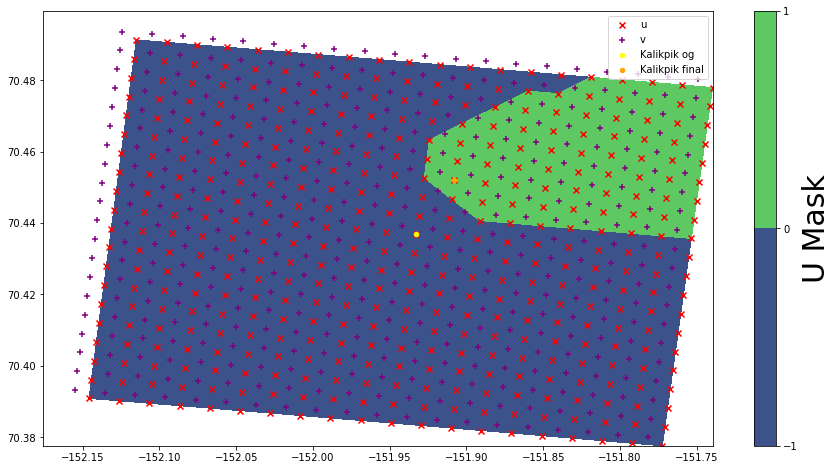

In [15]:
# Make a plot that is a scatter plot of u and v points 
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
cs2 = ax2.contourf(grid.lon_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
                    grid.lat_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
                    grid.mask_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, lev1)
ax2.scatter(grid.lon_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
            grid.lat_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values,
            color='red', marker='x', label='u')

ax2.scatter(grid.lon_v[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
            grid.lat_v[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values,
            color='purple', marker='+', label='v')


# Kalikpik
ax2.scatter(grid.lon_u[eta_kal_idx, xi_kal_idx].values, grid.lat_u[eta_kal_idx, xi_kal_idx].values, 
            marker='.', s=80, color='yellow', label='Kalikpik og')

eta_kal_idx_test = 23 #22
xi_kal_idx_test = 87

ax2.scatter(grid.lon_u[eta_kal_idx_test, xi_kal_idx_test].values, 
            grid.lat_u[eta_kal_idx_test, xi_kal_idx_test].values, 
            marker='.', s=80, color='orange', label='Kalikpik final')
ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [16]:
# Check that this spot is in the mask
print(grid.mask_u[eta_kal_idx_test,xi_kal_idx_test].values)
print(grid.mask_u[eta_kal_idx_test,xi_kal_idx_test+1].values)

# If so, save it to the list of river indices 
eta_riv_arr[0] = eta_kal_idx_test
xi_riv_arr[0] = xi_kal_idx_test

1.0
1.0


In [17]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"

# Since the Kalikpik River is set to flow across a u face, make this value 0
riv_dir_kal = 0

# Add this to the array
riv_direction_arr[0] = riv_dir_kal

In [18]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)
# ... is that discharge? I think so ...

# For Kalikpik, we want sign to be positive since we are 
# adding water to the cell to the right 
# Make a fake time series
#Q_kal = np.full((time_tmp_len), 1000) # m3/s

# Use Blaskey data
Q_kal = (river_data_kal['Discharge(m3/s)'][912:1037].values)/len_river_cells_kal # m3/s


# Add this to the array
riv_transport_arr[:,0] = Q_kal

In [19]:
# print(mean_river_dis.river_transport[182:307,0].values)
# print(time_tmp_len)
# print(mean_river_dis.river_transport[306,0].values)

In [20]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Since the Kalikpik River is in shallow water and we have no preference,
# do uniform distribution over all depths 
#riv_vshape_kal = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kal = vshape_all[:, eta_kal_idx_test, xi_kal_idx_test]

# Add this to the array
riv_vshape_arr[:,0] = riv_vshape_kal

In [21]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_kal_tmp = river_data_kal['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kal = np.full((time_tmp_len, s_rho_len), 11) 
# Make this the same in each layer 
riv_temp_kal = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kal[:,i] = riv_temp_kal_tmp

# Add this to the array
riv_temp_arr[:,:,0] = riv_temp_kal

In [22]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kal = np.full((time_tmp_len, s_rho_len), 0) 

# Add this to the array
riv_salt_arr[:,:,0] = riv_salt_kal

In [23]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kal = 10 / Q_kal 
# #riv_mud_01_kal = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kal = 10 / Q_kal
# #riv_mud_02_kal = np.full((time_tmp_len), 0.00001)


# ---Lamb and Toniolo 2016 Version---
#riv_mud_kal_tmp = calc_river_ssc_Anaktuvuk(Q_kal)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_kal_tmp = calc_river_ssc_Sag_DSS3(Q_kal)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_kal_tmp = calc_river_ssc_Sag_DSS2(Q_kal)

# Convert output from mg/L to kg/m3
riv_mud_kal = riv_mud_kal_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kal = riv_mud_kal/2
riv_mud_15_kal = riv_mud_kal/2


# Add these to the arrays
riv_mud_01_arr[:,0] = riv_mud_01_kal
riv_mud_15_arr[:,0] = riv_mud_15_kal

In [24]:
# # Check to see if this worked
# print('Q_kal: ', np.shape(Q_kal))
# print(Q_kal[100])
# print('riv_mud_kal: ', np.shape(riv_mud_kal))
# print(riv_mud_kal_tmp[100])
# print(riv_mud_kal[100])
# print('check math: ', 0.0199*((Q_kal[100])**1.4811))
# print('check division: ', riv_mud_01_kal[100])
# print('check division 02: ', riv_mud_02_kal[100])

# # It worked!

In [25]:
# Set all the other mud classes to 0 for this river

# mud 01
#riv_mud_01_kal = 0 / Q_kal

# mud 02 
riv_mud_02_kal = 0 / Q_kal

# mud 03
riv_mud_03_kal = 0 / Q_kal

# mud 04 
riv_mud_04_kal = 0 / Q_kal

# mud 05
riv_mud_05_kal = 0 / Q_kal

# mud 06
riv_mud_06_kal = 0 / Q_kal

# mud 07
riv_mud_07_kal = 0 / Q_kal

# mud 08
riv_mud_08_kal = 0 / Q_kal

# mud 09
riv_mud_09_kal = 0 / Q_kal

# mud 10
riv_mud_10_kal = 0 / Q_kal

# mud 11
riv_mud_11_kal = 0 / Q_kal

# mud 12
riv_mud_12_kal = 0 / Q_kal

# mud 13
riv_mud_13_kal = 0 / Q_kal

# mud 14
riv_mud_14_kal = 0 / Q_kal

# mud 15
#riv_mud_15_kal = 0 / Q_kal

# mud 16
riv_mud_16_kal = 0 / Q_kal

# mud 17
riv_mud_17_kal = 0 / Q_kal

# mud 18
riv_mud_18_kal = 0 / Q_kal

# mud 19
riv_mud_19_kal = 0 / Q_kal

# mud 20
riv_mud_20_kal = 0 / Q_kal

# mud 21
riv_mud_21_kal = 0 / Q_kal

# mud 22
riv_mud_22_kal = 0 / Q_kal

# mud 23
riv_mud_23_kal = 0 / Q_kal

# mud 24
riv_mud_24_kal = 0 / Q_kal

# mud 25
#riv_mud_25_kal = 0 / Q_kal

# mud 26
#riv_mud_26_kal = 0 / Q_kal

# mud 27
#riv_mud_27_kal = 0 / Q_kal

# mud 28
#riv_mud_28_kal = 0 / Q_kal

# mud 29
#riv_mud_29_kal = 0 / Q_kal

# mud 30
#riv_mud_30_kal = 0 / Q_kal

# Save these to the arrays 
#riv_mud_01_arr[:,0] = riv_mud_01_kal

riv_mud_02_arr[:,0] = riv_mud_02_kal
riv_mud_03_arr[:,0] = riv_mud_03_kal
riv_mud_04_arr[:,0] = riv_mud_04_kal
riv_mud_05_arr[:,0] = riv_mud_05_kal
riv_mud_06_arr[:,0] = riv_mud_06_kal
riv_mud_07_arr[:,0] = riv_mud_07_kal
riv_mud_08_arr[:,0] = riv_mud_08_kal
riv_mud_09_arr[:,0] = riv_mud_09_kal
riv_mud_10_arr[:,0] = riv_mud_10_kal
riv_mud_11_arr[:,0] = riv_mud_11_kal
riv_mud_12_arr[:,0] = riv_mud_12_kal
riv_mud_13_arr[:,0] = riv_mud_13_kal
riv_mud_14_arr[:,0] = riv_mud_14_kal

#riv_mud_15_arr[:,0] = riv_mud_15_kal

riv_mud_16_arr[:,0] = riv_mud_16_kal
riv_mud_17_arr[:,0] = riv_mud_17_kal
riv_mud_18_arr[:,0] = riv_mud_18_kal
riv_mud_19_arr[:,0] = riv_mud_19_kal
riv_mud_20_arr[:,0] = riv_mud_20_kal
riv_mud_21_arr[:,0] = riv_mud_21_kal
riv_mud_22_arr[:,0] = riv_mud_22_kal
riv_mud_23_arr[:,0] = riv_mud_23_kal
riv_mud_24_arr[:,0] = riv_mud_24_kal
#riv_mud_25_arr[:,0] = riv_mud_25_kal
#riv_mud_26_arr[:,0] = riv_mud_26_kal
#riv_mud_27_arr[:,0] = riv_mud_27_kal
#riv_mud_28_arr[:,0] = riv_mud_28_kal
#riv_mud_29_arr[:,0] = riv_mud_29_kal
#riv_mud_30_arr[:,0] = riv_mud_30_kal

In [26]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kal = 0 / Q_kal
#riv_sand_01_kal = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kal = 0 / Q_kal
#riv_sand_02_kal = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kal = 0 / Q_kal
#riv_sand_03_kal = np.full((time_tmp_len), 0.0)

# Add this to the array
riv_sand_01_arr[:,0] = riv_sand_01_kal
riv_sand_02_arr[:,0] = riv_sand_02_kal
riv_sand_03_arr[:,0] = riv_sand_03_kal

In [27]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Kailkpik
riv_id_kal = 1

# Add this to the array
riv_id_arr[0] = riv_id_kal

In [28]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kal = 3

# Add this to the array
riv_flag_arr[0] = riv_flag_kal

### Colville River 
Location: (70.4517, -150.3589)  
Width: 3500 m

In [29]:
# Colville River (70.4517, -150.3589), 3500 m
# Set the number of cells it will take 
# 3500 m / 750 m = 4.66 ~ 5 cells
len_river_cells_col = 6 # 6 cells to help with covering more of the coast 

# Find it manually
eta_col_idx = 34
xi_col_idx = 165

# Needs to be on u or v point, depending what makes sense here
# 
print('Colville Lat u: ', grid.lat_u[eta_col_idx, xi_col_idx].values)
print('Colville Lon u: ', grid.lon_u[eta_col_idx, xi_col_idx].values)

Colville Lat u:  70.44802546881658
Colville Lon u:  -150.35100528871192


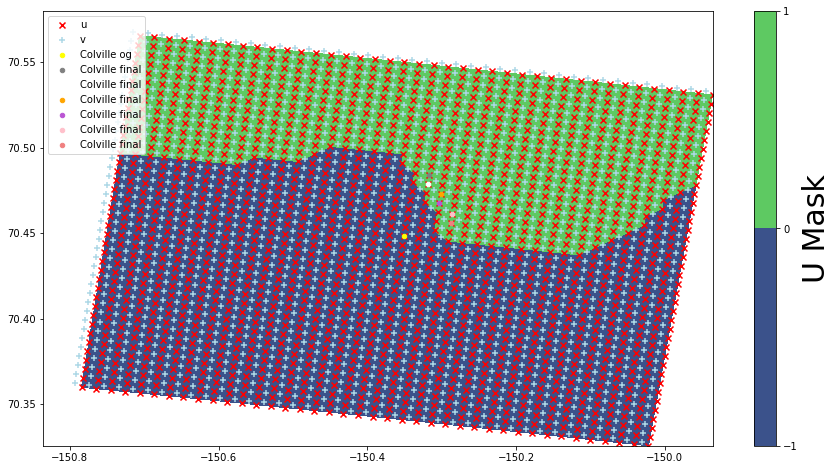

In [30]:
# Make a plot that is a scatter plot of u and v points 
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
cs2 = ax2.contourf(grid.lon_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
                    grid.lat_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
                    grid.mask_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, lev1)
ax2.scatter(grid.lon_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
            grid.lat_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values,
            color='red', marker='x', label='u')

ax2.scatter(grid.lon_v[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
            grid.lat_v[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values,
            color='lightblue', marker='+', label='v')


# Colville
ax2.scatter(grid.lon_u[eta_col_idx, xi_col_idx].values, grid.lat_u[eta_col_idx, xi_col_idx].values, 
            marker='.', s=80, color='yellow', label='Colville og')

# # ORIGINAL
# # Plot all 5 points - combo of u and v cells
# # Point 1 - u face
# eta_col_idx_test1 = 41
# xi_col_idx_test1 = 166 #165

# ax2.scatter(grid.lon_u[eta_col_idx_test1, xi_col_idx_test1].values, 
#             grid.lat_u[eta_col_idx_test1, xi_col_idx_test1].values, 
#             marker='.', s=80, color='gray', label='Colville final')

# # Point 2 - u face
# eta_col_idx_test2 = 40
# xi_col_idx_test2 = 166 #165

# ax2.scatter(grid.lon_u[eta_col_idx_test2, xi_col_idx_test2].values, 
#             grid.lat_u[eta_col_idx_test2, xi_col_idx_test2].values, 
#             marker='.', s=80, color='white', label='Colville final')

# # Point 3 - u face
# eta_col_idx_test3 = 39
# xi_col_idx_test3 = 167 #166

# ax2.scatter(grid.lon_u[eta_col_idx_test3, xi_col_idx_test3].values, 
#             grid.lat_u[eta_col_idx_test3, xi_col_idx_test3].values, 
#             marker='.', s=80, color='orange', label='Colville final')

# # Point 4 - u face
# eta_col_idx_test4 = 38
# xi_col_idx_test4 = 167 #166

# ax2.scatter(grid.lon_u[eta_col_idx_test4, xi_col_idx_test4].values, 
#             grid.lat_u[eta_col_idx_test4, xi_col_idx_test4].values, 
#             marker='.', s=80, color='mediumorchid', label='Colville final')

# # Point 5 - u face
# eta_col_idx_test5 = 37
# xi_col_idx_test5 = 168 #167

# ax2.scatter(grid.lon_u[eta_col_idx_test5, xi_col_idx_test5].values, 
#             grid.lat_u[eta_col_idx_test5, xi_col_idx_test5].values, 
#             marker='.', s=80, color='pink', label='Colville final')

# # Point 6 - u face
# eta_col_idx_test6 = 36
# xi_col_idx_test6 = 168 #167

# ax2.scatter(grid.lon_u[eta_col_idx_test6, xi_col_idx_test6].values, 
#             grid.lat_u[eta_col_idx_test6, xi_col_idx_test6].values, 
#             marker='.', s=80, color='lightcoral', label='Colville final')

# SCOOTED VERSION
# Scoot everything back one xi cell and see if river still appears
# Plot all 5 points - combo of u and v cells
# Point 1 - u face
eta_col_idx_test1 = 41
xi_col_idx_test1 = 166 #-1 #165

ax2.scatter(grid.lon_u[eta_col_idx_test1, xi_col_idx_test1].values, 
            grid.lat_u[eta_col_idx_test1, xi_col_idx_test1].values, 
            marker='.', s=80, color='gray', label='Colville final')

# Point 2 - u face
eta_col_idx_test2 = 40
xi_col_idx_test2 = 166 #-1 #165

ax2.scatter(grid.lon_u[eta_col_idx_test2, xi_col_idx_test2].values, 
            grid.lat_u[eta_col_idx_test2, xi_col_idx_test2].values, 
            marker='.', s=80, color='white', label='Colville final')

# Point 3 - u face
eta_col_idx_test3 = 39
xi_col_idx_test3 = 167 #-1 #166

ax2.scatter(grid.lon_u[eta_col_idx_test3, xi_col_idx_test3].values, 
            grid.lat_u[eta_col_idx_test3, xi_col_idx_test3].values, 
            marker='.', s=80, color='orange', label='Colville final')

# Point 4 - u face
eta_col_idx_test4 = 38
xi_col_idx_test4 = 167 #-1 #166

ax2.scatter(grid.lon_u[eta_col_idx_test4, xi_col_idx_test4].values, 
            grid.lat_u[eta_col_idx_test4, xi_col_idx_test4].values, 
            marker='.', s=80, color='mediumorchid', label='Colville final')

# Point 5 - u face
eta_col_idx_test5 = 37
xi_col_idx_test5 = 168 #-1 #167

ax2.scatter(grid.lon_u[eta_col_idx_test5, xi_col_idx_test5].values, 
            grid.lat_u[eta_col_idx_test5, xi_col_idx_test5].values, 
            marker='.', s=80, color='pink', label='Colville final')

# Point 6 - u face
eta_col_idx_test6 = 36
xi_col_idx_test6 = 168 #-1 #167

ax2.scatter(grid.lon_u[eta_col_idx_test6, xi_col_idx_test6].values, 
            grid.lat_u[eta_col_idx_test6, xi_col_idx_test6].values, 
            marker='.', s=80, color='lightcoral', label='Colville final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [31]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_col_idx_test1,xi_col_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[1] = eta_col_idx_test1
xi_riv_arr[1] = xi_col_idx_test1

# Point 2 - u 
print(grid.mask_u[eta_col_idx_test2,xi_col_idx_test2].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[2] = eta_col_idx_test2
xi_riv_arr[2] = xi_col_idx_test2

# Point 3 - u 
print(grid.mask_u[eta_col_idx_test3,xi_col_idx_test3].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[3] = eta_col_idx_test3
xi_riv_arr[3] = xi_col_idx_test3

# Point 4 - u
print(grid.mask_u[eta_col_idx_test4,xi_col_idx_test4].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[4] = eta_col_idx_test4
xi_riv_arr[4] = xi_col_idx_test4

# Point 5 - u
print(grid.mask_u[eta_col_idx_test5,xi_col_idx_test5].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[5] = eta_col_idx_test5
xi_riv_arr[5] = xi_col_idx_test5

# Point 6 - u
print(grid.mask_u[eta_col_idx_test6,xi_col_idx_test6].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[6] = eta_col_idx_test6
xi_riv_arr[6] = xi_col_idx_test6

1.0
1.0
1.0
1.0
1.0
1.0


In [32]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_col1 = 0
riv_dir_col2 = 0
riv_dir_col3 = 0 
riv_dir_col4 = 0
riv_dir_col5 = 0
riv_dir_col6 = 0

# Add this to the list 
riv_direction_arr[1] = riv_dir_col1
riv_direction_arr[2] = riv_dir_col2
riv_direction_arr[3] = riv_dir_col3
riv_direction_arr[4] = riv_dir_col4
riv_direction_arr[5] = riv_dir_col5
riv_direction_arr[6] = riv_dir_col6

In [33]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# For Colville, we want sign to be positive since we are 
# adding water to the cell to the right and above

# Use Blaskey data
Q_col1 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col
Q_col2 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col
Q_col3 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col
Q_col4 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col
Q_col5 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col
Q_col6 = (river_data_col['Discharge(m3/s)'][912:1037].values)/len_river_cells_col

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,1] = Q_col1
riv_transport_arr[:,2] = Q_col2
riv_transport_arr[:,3] = Q_col3
riv_transport_arr[:,4] = Q_col4
riv_transport_arr[:,5] = Q_col5
riv_transport_arr[:,6] = Q_col6

In [34]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_col = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_col1 = vshape_all[:, eta_col_idx_test1, xi_col_idx_test1]
riv_vshape_col2 = vshape_all[:, eta_col_idx_test2, xi_col_idx_test2]
riv_vshape_col3 = vshape_all[:, eta_col_idx_test3, xi_col_idx_test3]
riv_vshape_col4 = vshape_all[:, eta_col_idx_test4, xi_col_idx_test4]
riv_vshape_col5 = vshape_all[:, eta_col_idx_test5, xi_col_idx_test5]
riv_vshape_col6 = vshape_all[:, eta_col_idx_test6, xi_col_idx_test6]

# Add this to the array
riv_vshape_arr[:,1] = riv_vshape_col1
riv_vshape_arr[:,2] = riv_vshape_col2
riv_vshape_arr[:,3] = riv_vshape_col3
riv_vshape_arr[:,4] = riv_vshape_col4
riv_vshape_arr[:,5] = riv_vshape_col5
riv_vshape_arr[:,6] = riv_vshape_col6

In [35]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_col_tmp = river_data_col['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_col = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_col = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_col[:,i] = riv_temp_col_tmp

# Add this to the array 
riv_temp_arr[:,:,1] = riv_temp_col
riv_temp_arr[:,:,2] = riv_temp_col
riv_temp_arr[:,:,3] = riv_temp_col
riv_temp_arr[:,:,4] = riv_temp_col
riv_temp_arr[:,:,5] = riv_temp_col
riv_temp_arr[:,:,6] = riv_temp_col

In [36]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_col = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,1] = riv_salt_col
riv_salt_arr[:,:,2] = riv_salt_col
riv_salt_arr[:,:,3] = riv_salt_col
riv_salt_arr[:,:,4] = riv_salt_col
riv_salt_arr[:,:,5] = riv_salt_col
riv_salt_arr[:,:,6] = riv_salt_col

In [37]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# This is only a time series but maybe can be for different sediment classes?
# (might have a vertical component)

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_col = 10 / Q_col1 # when there is real data, may need one for each cell
# #riv_mud_01_col = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_col = 10 / Q_col1 # when there is real data, may need one for each cell
# #riv_mud_02_col = np.full((time_tmp_len), 0.00001)

# ---Lamb and Toniolo 2016 Version---
#riv_mud_col_tmp = calc_river_ssc_Anaktuvuk(Q_col1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_col_tmp = calc_river_ssc_Sag_DSS3(Q_col1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_col_tmp = calc_river_ssc_Sag_DSS2(Q_col1)

# Convert output from mg/L to kg/m3
riv_mud_col = riv_mud_col_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_col = riv_mud_col/2
riv_mud_16_col = riv_mud_col/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,1] = riv_mud_01_col
riv_mud_01_arr[:,2] = riv_mud_01_col
riv_mud_01_arr[:,3] = riv_mud_01_col
riv_mud_01_arr[:,4] = riv_mud_01_col
riv_mud_01_arr[:,5] = riv_mud_01_col
riv_mud_01_arr[:,6] = riv_mud_01_col

# mud 16
riv_mud_16_arr[:,1] = riv_mud_16_col
riv_mud_16_arr[:,2] = riv_mud_16_col
riv_mud_16_arr[:,3] = riv_mud_16_col
riv_mud_16_arr[:,4] = riv_mud_16_col
riv_mud_16_arr[:,5] = riv_mud_16_col
riv_mud_16_arr[:,6] = riv_mud_16_col

In [38]:
# Set all the other mud classes to 0 for this river

# mud 01
#riv_mud_01_col = 0 / Q_col1

# mud 02 
riv_mud_02_col = 0 / Q_col1

# mud 03
riv_mud_03_col = 0 / Q_col1

# mud 04
riv_mud_04_col = 0 / Q_col1

# mud 05
riv_mud_05_col = 0 / Q_col1

# mud 06
riv_mud_06_col = 0 / Q_col1

# mud 07
riv_mud_07_col = 0 / Q_col1

# mud 08
riv_mud_08_col = 0 / Q_col1

# mud 09
riv_mud_09_col = 0 / Q_col1

# mud 10
riv_mud_10_col = 0 / Q_col1

# mud 11
riv_mud_11_col = 0 / Q_col1

# mud 12
riv_mud_12_col = 0 / Q_col1

# mud 13
riv_mud_13_col = 0 / Q_col1

# mud 14
riv_mud_14_col = 0 / Q_col1

# mud 15
riv_mud_15_col = 0 / Q_col1

# mud 16
#riv_mud_16_col = 0 / Q_col1

# mud 17
riv_mud_17_col = 0 / Q_col1

# mud 18
riv_mud_18_col = 0 / Q_col1

# mud 19
riv_mud_19_col = 0 / Q_col1

# mud 20
riv_mud_20_col = 0 / Q_col1

# mud 21
riv_mud_21_col = 0 / Q_col1

# mud 22
riv_mud_22_col = 0 / Q_col1

# mud 23
riv_mud_23_col = 0 / Q_col1

# mud 24
riv_mud_24_col = 0 / Q_col1

# mud 25
#riv_mud_25_col = 0 / Q_col1

# mud 26
#riv_mud_26_col = 0 / Q_col1

# mud 27
#riv_mud_27_col = 0 / Q_col1

# mud 28
#riv_mud_28_col = 0 / Q_col1

# mud 29
#riv_mud_29_col = 0 / Q_col1

# mud 30
#riv_mud_30_col = 0 / Q_col1

# Save these to the arrays 
# Loop
for k in range(len_river_cells_col):
    print('k+1: ', k+1)
    
    #riv_mud_01_arr[:,k+1] = riv_mud_01_col
    
    riv_mud_02_arr[:,k+1] = riv_mud_02_col
    riv_mud_03_arr[:,k+1] = riv_mud_03_col
    riv_mud_04_arr[:,k+1] = riv_mud_04_col
    riv_mud_05_arr[:,k+1] = riv_mud_05_col
    riv_mud_06_arr[:,k+1] = riv_mud_06_col
    riv_mud_07_arr[:,k+1] = riv_mud_07_col
    riv_mud_08_arr[:,k+1] = riv_mud_08_col
    riv_mud_09_arr[:,k+1] = riv_mud_09_col
    riv_mud_10_arr[:,k+1] = riv_mud_10_col
    riv_mud_11_arr[:,k+1] = riv_mud_11_col
    riv_mud_12_arr[:,k+1] = riv_mud_12_col
    riv_mud_13_arr[:,k+1] = riv_mud_13_col
    riv_mud_14_arr[:,k+1] = riv_mud_14_col
    riv_mud_15_arr[:,k+1] = riv_mud_15_col
    #riv_mud_16_arr[:,k+1] = riv_mud_16_col
    riv_mud_17_arr[:,k+1] = riv_mud_17_col
    riv_mud_18_arr[:,k+1] = riv_mud_18_col
    riv_mud_19_arr[:,k+1] = riv_mud_19_col
    riv_mud_20_arr[:,k+1] = riv_mud_20_col
    riv_mud_21_arr[:,k+1] = riv_mud_21_col
    riv_mud_22_arr[:,k+1] = riv_mud_22_col
    riv_mud_23_arr[:,k+1] = riv_mud_23_col
    riv_mud_24_arr[:,k+1] = riv_mud_24_col
    #riv_mud_25_arr[:,k+1] = riv_mud_25_col
    #riv_mud_26_arr[:,k+1] = riv_mud_26_col
    #riv_mud_27_arr[:,k+1] = riv_mud_27_col
    #riv_mud_28_arr[:,k+1] = riv_mud_28_col
    #riv_mud_29_arr[:,k+1] = riv_mud_29_col
    #riv_mud_30_arr[:,k+1] = riv_mud_30_col
    
# riv_mud_01_arr[:,1:7] = riv_mud_01_col
# riv_mud_02_arr[:,1:7] = riv_mud_02_col

# riv_mud_03_arr[:,1:7] = riv_mud_03_col
# riv_mud_04_arr[:,1:7] = riv_mud_04_col

# riv_mud_07_arr[:,1:7] = riv_mud_07_col
# riv_mud_08_arr[:,1:7] = riv_mud_08_col
# riv_mud_09_arr[:,1:7] = riv_mud_09_col
# riv_mud_10_arr[:,1:7] = riv_mud_10_col
# riv_mud_11_arr[:,1:7] = riv_mud_11_col
# riv_mud_12_arr[:,1:7] = riv_mud_12_col
# riv_mud_13_arr[:,1:7] = riv_mud_13_col
# riv_mud_14_arr[:,1:7] = riv_mud_14_col
# riv_mud_15_arr[:,1:7] = riv_mud_15_col
# riv_mud_16_arr[:,1:7] = riv_mud_16_col
# riv_mud_17_arr[:,1:7] = riv_mud_17_col
# riv_mud_18_arr[:,1:7] = riv_mud_18_col
# riv_mud_19_arr[:,1:7] = riv_mud_19_col
# riv_mud_20_arr[:,1:7] = riv_mud_20_col
# riv_mud_21_arr[:,1:7] = riv_mud_21_col
# riv_mud_22_arr[:,1:7] = riv_mud_22_col
# riv_mud_23_arr[:,1:7] = riv_mud_23_col
# riv_mud_24_arr[:,1:7] = riv_mud_24_col
# riv_mud_25_arr[:,1:7] = riv_mud_25_col
# riv_mud_26_arr[:,1:7] = riv_mud_26_col
# riv_mud_27_arr[:,1:7] = riv_mud_27_col
# riv_mud_28_arr[:,1:7] = riv_mud_28_col
# riv_mud_29_arr[:,1:7] = riv_mud_29_col
# riv_mud_30_arr[:,1:7] = riv_mud_30_col

k+1:  1
k+1:  2
k+1:  3
k+1:  4
k+1:  5
k+1:  6


In [39]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_01_col = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_02_col = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_03_col = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,1] = riv_sand_01_col
riv_sand_01_arr[:,2] = riv_sand_01_col
riv_sand_01_arr[:,3] = riv_sand_01_col
riv_sand_01_arr[:,4] = riv_sand_01_col
riv_sand_01_arr[:,5] = riv_sand_01_col
riv_sand_01_arr[:,6] = riv_sand_01_col

# sand 02
riv_sand_02_arr[:,1] = riv_sand_02_col
riv_sand_02_arr[:,2] = riv_sand_02_col
riv_sand_02_arr[:,3] = riv_sand_02_col
riv_sand_02_arr[:,4] = riv_sand_02_col
riv_sand_02_arr[:,5] = riv_sand_02_col
riv_sand_02_arr[:,6] = riv_sand_02_col

# sand 03
riv_sand_03_arr[:,1] = riv_sand_03_col
riv_sand_03_arr[:,2] = riv_sand_03_col
riv_sand_03_arr[:,3] = riv_sand_03_col
riv_sand_03_arr[:,4] = riv_sand_03_col
riv_sand_03_arr[:,5] = riv_sand_03_col
riv_sand_03_arr[:,6] = riv_sand_03_col

In [40]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Colville
riv_id_col = 2

# Add this to the array
riv_id_arr[1] = riv_id_col
riv_id_arr[2] = riv_id_col
riv_id_arr[3] = riv_id_col
riv_id_arr[4] = riv_id_col
riv_id_arr[5] = riv_id_col
riv_id_arr[6] = riv_id_col

In [41]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
#riv_flag_col = np.full(len_river_cells_kal, 3)
riv_flag_col = 3

# Add this to the array
riv_flag_arr[1] = riv_flag_col
riv_flag_arr[2] = riv_flag_col
riv_flag_arr[3] = riv_flag_col
riv_flag_arr[4] = riv_flag_col
riv_flag_arr[5] = riv_flag_col
riv_flag_arr[6] = riv_flag_col

## Sagavanirktok River 
Location: (70.2924, -148.1712)  
Width: 2000 m  

In [42]:
# Sagavanirktok River (70.2924, -148.1712), 2000 m 
# Set the number of cells it will take 
# 2000 m / 750 m = 2.66 ~ 3 cells
len_river_cells_sag = 3

# Find it manually
eta_sag_idx = 26
xi_sag_idx = 278

# Needs to be on u or v point, depending what makes sense here
print('Sagavanirktok Lat v: ', grid.lat_v[eta_sag_idx, xi_sag_idx].values)
print('Sagavanirktok Lon v: ', grid.lon_v[eta_sag_idx, xi_sag_idx].values)

Sagavanirktok Lat v:  70.29447461133175
Sagavanirktok Lon v:  -148.17284730899166


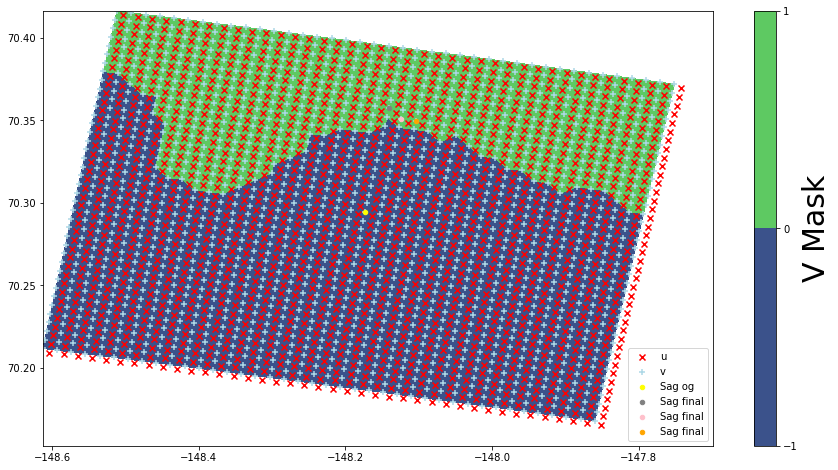

In [43]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
                    grid.lat_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
                    grid.mask_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
            grid.lat_u[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
            grid.lat_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values,
            color='lightblue', marker='+', label='v')


# Sagavanirktok
ax2.scatter(grid.lon_v[eta_sag_idx, xi_sag_idx].values, grid.lat_v[eta_sag_idx, xi_sag_idx].values, 
            marker='.', s=80, color='yellow', label='Sag og')

# Plot all 3 points - combo of u and v cells
# Point 1 - v face
eta_sag_idx_test1 = 38 #37
xi_sag_idx_test1 = 278

ax2.scatter(grid.lon_v[eta_sag_idx_test1, xi_sag_idx_test1].values, 
            grid.lat_v[eta_sag_idx_test1, xi_sag_idx_test1].values, 
            marker='.', s=80, color='gray', label='Sag final')

# Point 2 - v face
eta_sag_idx_test2 = 37 #36
xi_sag_idx_test2 = 279

ax2.scatter(grid.lon_v[eta_sag_idx_test2, xi_sag_idx_test2].values, 
            grid.lat_v[eta_sag_idx_test2, xi_sag_idx_test2].values, 
            marker='.', s=80, color='pink', label='Sag final')

# Point 3 - v face
eta_sag_idx_test3 = 37 #36
xi_sag_idx_test3 = 280

ax2.scatter(grid.lon_v[eta_sag_idx_test3, xi_sag_idx_test3].values, 
            grid.lat_v[eta_sag_idx_test3, xi_sag_idx_test3].values, 
            marker='.', s=80, color='orange', label='Sag final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [44]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_sag_idx_test1,xi_sag_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[7] = eta_sag_idx_test1
xi_riv_arr[7] = xi_sag_idx_test1

# Point 2 - v 
print(grid.mask_v[eta_sag_idx_test2,xi_sag_idx_test2].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[8] = eta_sag_idx_test2
xi_riv_arr[8] = xi_sag_idx_test2

# Point 3 - v 
print(grid.mask_v[eta_sag_idx_test3,xi_sag_idx_test3].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[9] = eta_sag_idx_test3
xi_riv_arr[9] = xi_sag_idx_test3

1.0
1.0
1.0


In [45]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sag1 = 1
riv_dir_sag2 = 1
riv_dir_sag3 = 1 

# Add this to the list 
riv_direction_arr[7] = riv_dir_sag1
riv_direction_arr[8] = riv_dir_sag2
riv_direction_arr[9] = riv_dir_sag3

In [46]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_sag1 = (river_data_sag['Discharge(m3/s)'][912:1037].values)/len_river_cells_sag
Q_sag2 = (river_data_sag['Discharge(m3/s)'][912:1037].values)/len_river_cells_sag
Q_sag3 = (river_data_sag['Discharge(m3/s)'][912:1037].values)/len_river_cells_sag

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,7] = Q_sag1
riv_transport_arr[:,8] = Q_sag2
riv_transport_arr[:,9] = Q_sag3

In [47]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sag = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sag1 = vshape_all[:, eta_sag_idx_test1, xi_sag_idx_test1]
riv_vshape_sag2 = vshape_all[:, eta_sag_idx_test2, xi_sag_idx_test2]
riv_vshape_sag3 = vshape_all[:, eta_sag_idx_test3, xi_sag_idx_test3]

# Add this to the array
riv_vshape_arr[:,7] = riv_vshape_sag1
riv_vshape_arr[:,8] = riv_vshape_sag2
riv_vshape_arr[:,9] = riv_vshape_sag3

In [48]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_sag_tmp = river_data_sag['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sag = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sag = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sag[:,i] = riv_temp_sag_tmp

# Add this to the array 
riv_temp_arr[:,:,7] = riv_temp_sag
riv_temp_arr[:,:,8] = riv_temp_sag
riv_temp_arr[:,:,9] = riv_temp_sag

In [49]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sag = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,7] = riv_salt_sag
riv_salt_arr[:,:,8] = riv_salt_sag
riv_salt_arr[:,:,9] = riv_salt_sag

In [50]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sag = 10 / Q_sag1 # when there is real data, may need one for each cell
# #riv_mud_01_sag = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sag = 10 / Q_sag1 # when there is real data, may need one for each cell
# #riv_mud_02_sag = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_sag_tmp = calc_river_ssc_Anaktuvuk(Q_sag1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_sag_tmp = calc_river_ssc_Sag_DSS3(Q_sag1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_sag_tmp = calc_river_ssc_Sag_DSS2(Q_sag1)

# Convert output from mg/L to kg/m3
riv_mud_sag = riv_mud_sag_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sag = riv_mud_sag/2
riv_mud_17_sag = riv_mud_sag/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,7] = riv_mud_01_sag
riv_mud_01_arr[:,8] = riv_mud_01_sag
riv_mud_01_arr[:,9] = riv_mud_01_sag

# mud 17
riv_mud_17_arr[:,7] = riv_mud_17_sag
riv_mud_17_arr[:,8] = riv_mud_17_sag
riv_mud_17_arr[:,9] = riv_mud_17_sag

In [51]:
# Set all the other mud classes to 0 for this river

# mud 01
#riv_mud_01_sag = 0 / Q_sag1

# mud 02 
riv_mud_02_sag = 0 / Q_sag1

# mud 03
riv_mud_03_sag = 0 / Q_sag1

# mud 04
riv_mud_04_sag = 0 / Q_sag1

# mud 05
riv_mud_05_sag = 0 / Q_sag1

# mud 06
riv_mud_06_sag = 0 / Q_sag1

# mud 07
riv_mud_07_sag = 0 / Q_sag1

# mud 08
riv_mud_08_sag = 0 / Q_sag1

# mud 09
riv_mud_09_sag = 0 / Q_sag1

# mud 10
riv_mud_10_sag = 0 / Q_sag1

# mud 11
riv_mud_11_sag = 0 / Q_sag1

# mud 12
riv_mud_12_sag = 0 / Q_sag1

# mud 13
riv_mud_13_sag = 0 / Q_sag1

# mud 14
riv_mud_14_sag = 0 / Q_sag1

# mud 15
riv_mud_15_sag = 0 / Q_sag1

# mud 16
riv_mud_16_sag = 0 / Q_sag1

# mud 17
#riv_mud_17_sag = 0 / Q_sag1

# mud 18
riv_mud_18_sag = 0 / Q_sag1

# mud 19
riv_mud_19_sag = 0 / Q_sag1

# mud 20
riv_mud_20_sag = 0 / Q_sag1

# mud 21
riv_mud_21_sag = 0 / Q_sag1

# mud 22
riv_mud_22_sag = 0 / Q_sag1

# mud 23
riv_mud_23_sag = 0 / Q_sag1

# mud 24
riv_mud_24_sag = 0 / Q_sag1

# mud 25
#riv_mud_25_sag = 0 / Q_sag1

# mud 26
#riv_mud_26_sag = 0 / Q_sag1

# mud 27
#riv_mud_27_sag = 0 / Q_sag1

# mud 28
#riv_mud_28_sag = 0 / Q_sag1

# mud 29
#riv_mud_29_sag = 0 / Q_sag1

# mud 30
#riv_mud_30_sag = 0 / Q_sag1

# Save these to the arrays
# Loop
for k in range(len_river_cells_sag):
    print('k+7: ', k+7)
    
    #riv_mud_01_arr[:,k+7] = riv_mud_01_sag
    
    riv_mud_02_arr[:,k+7] = riv_mud_02_sag
    riv_mud_03_arr[:,k+7] = riv_mud_03_sag
    riv_mud_04_arr[:,k+7] = riv_mud_04_sag
    riv_mud_05_arr[:,k+7] = riv_mud_05_sag
    riv_mud_06_arr[:,k+7] = riv_mud_06_sag
    riv_mud_07_arr[:,k+7] = riv_mud_07_sag
    riv_mud_08_arr[:,k+7] = riv_mud_08_sag
    riv_mud_09_arr[:,k+7] = riv_mud_09_sag
    riv_mud_10_arr[:,k+7] = riv_mud_10_sag
    riv_mud_11_arr[:,k+7] = riv_mud_11_sag
    riv_mud_12_arr[:,k+7] = riv_mud_12_sag
    riv_mud_13_arr[:,k+7] = riv_mud_13_sag
    riv_mud_14_arr[:,k+7] = riv_mud_14_sag
    riv_mud_15_arr[:,k+7] = riv_mud_15_sag
    riv_mud_16_arr[:,k+7] = riv_mud_16_sag
    #riv_mud_17_arr[:,k+7] = riv_mud_17_sag
    riv_mud_18_arr[:,k+7] = riv_mud_18_sag
    riv_mud_19_arr[:,k+7] = riv_mud_19_sag
    riv_mud_20_arr[:,k+7] = riv_mud_20_sag
    riv_mud_21_arr[:,k+7] = riv_mud_21_sag
    riv_mud_22_arr[:,k+7] = riv_mud_22_sag
    riv_mud_23_arr[:,k+7] = riv_mud_23_sag
    riv_mud_24_arr[:,k+7] = riv_mud_24_sag
    #riv_mud_25_arr[:,k+7] = riv_mud_25_sag
    #riv_mud_26_arr[:,k+7] = riv_mud_26_sag
    #riv_mud_27_arr[:,k+7] = riv_mud_27_sag
    #riv_mud_28_arr[:,k+7] = riv_mud_28_sag
    #riv_mud_29_arr[:,k+7] = riv_mud_29_sag
    #riv_mud_30_arr[:,k+7] = riv_mud_30_sag
    
    
# riv_mud_01_arr[:,7:10] = riv_mud_01_sag
# riv_mud_02_arr[:,7:10] = riv_mud_02_sag

# riv_mud_03_arr[:,7:10] = riv_mud_03_sag
# riv_mud_04_arr[:,7:10] = riv_mud_04_sag
# riv_mud_05_arr[:,7:10] = riv_mud_05_sag
# riv_mud_06_arr[:,7:10] = riv_mud_06_sag

# riv_mud_09_arr[:,7:10] = riv_mud_09_sag
# riv_mud_10_arr[:,7:10] = riv_mud_10_sag
# riv_mud_11_arr[:,7:10] = riv_mud_11_sag
# riv_mud_12_arr[:,7:10] = riv_mud_12_sag
# riv_mud_13_arr[:,7:10] = riv_mud_13_sag
# riv_mud_14_arr[:,7:10] = riv_mud_14_sag
# riv_mud_15_arr[:,7:10] = riv_mud_15_sag
# riv_mud_16_arr[:,7:10] = riv_mud_16_sag
# riv_mud_17_arr[:,7:10] = riv_mud_17_sag
# riv_mud_18_arr[:,7:10] = riv_mud_18_sag
# riv_mud_19_arr[:,7:10] = riv_mud_19_sag
# riv_mud_20_arr[:,7:10] = riv_mud_20_sag
# riv_mud_21_arr[:,7:10] = riv_mud_21_sag
# riv_mud_22_arr[:,7:10] = riv_mud_22_sag
# riv_mud_23_arr[:,7:10] = riv_mud_23_sag
# riv_mud_24_arr[:,7:10] = riv_mud_24_sag
# riv_mud_25_arr[:,7:10] = riv_mud_25_sag
# riv_mud_26_arr[:,7:10] = riv_mud_26_sag
# riv_mud_27_arr[:,7:10] = riv_mud_27_sag
# riv_mud_28_arr[:,7:10] = riv_mud_28_sag
# riv_mud_29_arr[:,7:10] = riv_mud_29_sag
# riv_mud_30_arr[:,7:10] = riv_mud_30_sag

k+7:  7
k+7:  8
k+7:  9


In [52]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_01_sag = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_02_sag = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_03_sag = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,7] = riv_sand_01_sag
riv_sand_01_arr[:,8] = riv_sand_01_sag
riv_sand_01_arr[:,9] = riv_sand_01_sag

# sand 02
riv_sand_02_arr[:,7] = riv_sand_02_sag
riv_sand_02_arr[:,8] = riv_sand_02_sag
riv_sand_02_arr[:,9] = riv_sand_02_sag

# sand 03
riv_sand_03_arr[:,7] = riv_sand_03_sag
riv_sand_03_arr[:,8] = riv_sand_03_sag
riv_sand_03_arr[:,9] = riv_sand_03_sag

In [53]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Sagavanirktok
riv_id_sag = 3

# Add this to the array
riv_id_arr[7] = riv_id_sag
riv_id_arr[8] = riv_id_sag
riv_id_arr[9] = riv_id_sag

In [54]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
#riv_flag_sag = np.full(len_river_cells_sag, 3)
riv_flag_sag = 3

# Add this to the array
riv_flag_arr[7] = riv_flag_sag
riv_flag_arr[8] = riv_flag_sag
riv_flag_arr[9] = riv_flag_sag

## Fish Creek 
Location: 70.3786, -151.3608  
Width: 405.9 m  

In [55]:
# Fish Creek (70.3786, -151.3608), 405.9 m
# Set the number of cells it will take 
# 405.9 m / 750 m = 0.5412 ~ 1 cell
len_river_cells_fis = 1

# Find it manually
eta_fis_idx = 12
xi_fis_idx = 115

# Needs to be on u or v point, depending what makes sense here
print('Fish Creek Lat u: ', grid.lat_u[eta_fis_idx, xi_fis_idx].values)
print('Fish Creek Lon u: ', grid.lon_u[eta_fis_idx, xi_fis_idx].values)

Fish Creek Lat u:  70.37329673013637
Fish Creek Lon u:  -151.3762640291327


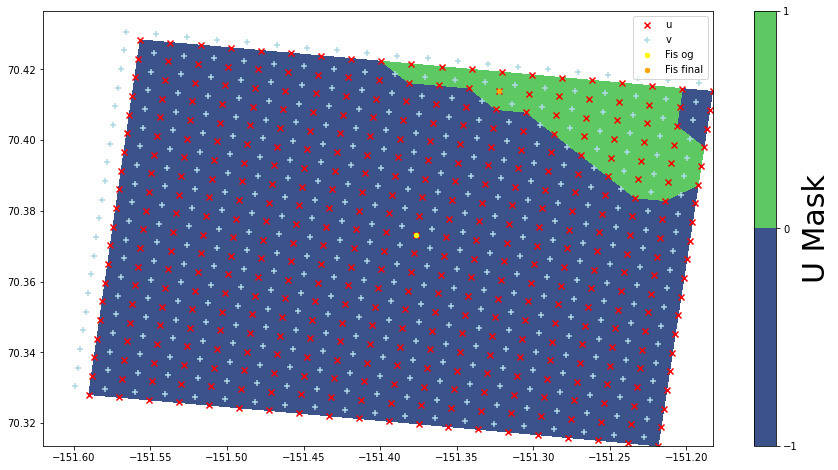

In [56]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.mask_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='lightblue', marker='+', label='v')


# Fish Creek
ax2.scatter(grid.lon_u[eta_fis_idx, xi_fis_idx].values, grid.lat_u[eta_fis_idx, xi_fis_idx].values, 
            marker='.', s=80, color='yellow', label='Fis og')

# Point 1 - u face
eta_fis_idx_test1 = 20
xi_fis_idx_test1 = 117 #116

ax2.scatter(grid.lon_u[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            grid.lat_u[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            marker='.', s=80, color='orange', label='Fis final')


ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [57]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_fis_idx_test1,xi_fis_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
#eta_riv_arr[10] = eta_fis_idx_test1
#xi_riv_arr[10] = xi_fis_idx_test1

1.0


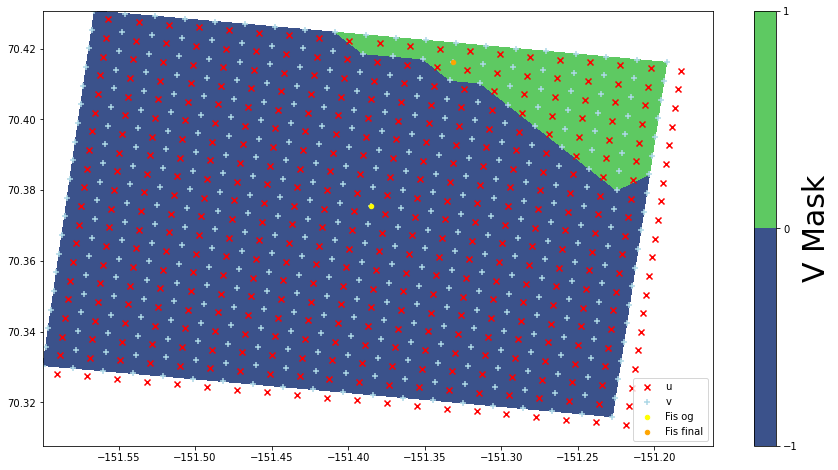

In [58]:
###### CHECK THE V_VERSION #####
# We are going with v for now 
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.mask_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='lightblue', marker='+', label='v')


# Fish Creek
ax2.scatter(grid.lon_v[eta_fis_idx, xi_fis_idx].values, grid.lat_v[eta_fis_idx, xi_fis_idx].values, 
            marker='.', s=80, color='yellow', label='Fis og')

# Point 1 - u face
eta_fis_idx_test1 = 20
xi_fis_idx_test1 = 117 #116

ax2.scatter(grid.lon_v[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            grid.lat_v[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            marker='.', s=80, color='orange', label='Fis final')


ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [59]:
###### CHECK THE V_VERSION #####
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_fis_idx_test1,xi_fis_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[10] = eta_fis_idx_test1
xi_riv_arr[10] = xi_fis_idx_test1

1.0


In [60]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
#riv_dir_fis1 = 0
riv_dir_fis1 = 1 # NEW

# Add this to the list 
riv_direction_arr[10] = riv_dir_fis1

In [61]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_fis1 = (river_data_fis['Discharge(m3/s)'][912:1037].values)/len_river_cells_fis

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,10] = Q_fis1

In [62]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_fis = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_fis = vshape_all[:, eta_fis_idx_test1, xi_fis_idx_test1]

# Add this to the array
riv_vshape_arr[:,10] = riv_vshape_fis

In [63]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_fis_tmp = river_data_fis['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_fis = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_fis = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_fis[:,i] = riv_temp_fis_tmp

# Add this to the array 
riv_temp_arr[:,:,10] = riv_temp_fis

In [64]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_fis = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,10] = riv_salt_fis

In [65]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_fis = 10 / Q_fis1 # when there is real data, may need one for each cell
# #riv_mud_01_fis = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_fis = 10 / Q_fis1 # when there is real data, may need one for each cell
# #riv_mud_02_fis = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_fis_tmp = calc_river_ssc_Anaktuvuk(Q_fis1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_fis_tmp = calc_river_ssc_Sag_DSS3(Q_fis1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_fis_tmp = calc_river_ssc_Sag_DSS2(Q_fis1)

# Convert output from mg/L to kg/m3
riv_mud_fis = riv_mud_fis_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_fis = riv_mud_fis/2
riv_mud_18_fis = riv_mud_fis/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,10] = riv_mud_01_fis

# mud 18
riv_mud_18_arr[:,10] = riv_mud_18_fis

In [66]:
# Set all the other mud classes to 0 for this river

# mud 01
#riv_mud_01_fis = 0 / Q_fis1

# mud 02 
riv_mud_02_fis = 0 / Q_fis1

# mud 03
riv_mud_03_fis = 0 / Q_fis1

# mud 04
riv_mud_04_fis = 0 / Q_fis1

# mud 05
riv_mud_05_fis = 0 / Q_fis1

# mud 06
riv_mud_06_fis = 0 / Q_fis1

# mud 07
riv_mud_07_fis = 0 / Q_fis1

# mud 08
riv_mud_08_fis = 0 / Q_fis1

# mud 09
riv_mud_09_fis = 0 / Q_fis1

# mud 10
riv_mud_10_fis = 0 / Q_fis1

# mud 11
riv_mud_11_fis = 0 / Q_fis1

# mud 12
riv_mud_12_fis = 0 / Q_fis1

# mud 13
riv_mud_13_fis = 0 / Q_fis1

# mud 14
riv_mud_14_fis = 0 / Q_fis1

# mud 15
riv_mud_15_fis = 0 / Q_fis1

# mud 16
riv_mud_16_fis = 0 / Q_fis1

# mud 17
riv_mud_17_fis = 0 / Q_fis1

# mud 18
#riv_mud_18_fis = 0 / Q_fis1

# mud 19
riv_mud_19_fis = 0 / Q_fis1

# mud 20
riv_mud_20_fis = 0 / Q_fis1

# mud 21
riv_mud_21_fis = 0 / Q_fis1

# mud 22
riv_mud_22_fis = 0 / Q_fis1

# mud 23
riv_mud_23_fis = 0 / Q_fis1

# mud 24
riv_mud_24_fis = 0 / Q_fis1

# mud 25
#riv_mud_25_fis = 0 / Q_fis1

# mud 26
#riv_mud_26_fis = 0 / Q_fis1

# mud 27
#riv_mud_27_fis = 0 / Q_fis1

# mud 28
#riv_mud_28_fis = 0 / Q_fis1

# mud 29
#riv_mud_29_fis = 0 / Q_fis1

# mud 30
#riv_mud_30_fis = 0 / Q_fis1

# Save these to the arrays 
#riv_mud_01_arr[:,10] = riv_mud_01_fis

riv_mud_02_arr[:,10] = riv_mud_02_fis
riv_mud_03_arr[:,10] = riv_mud_03_fis
riv_mud_04_arr[:,10] = riv_mud_04_fis
riv_mud_05_arr[:,10] = riv_mud_05_fis
riv_mud_06_arr[:,10] = riv_mud_06_fis
riv_mud_07_arr[:,10] = riv_mud_07_fis
riv_mud_08_arr[:,10] = riv_mud_08_fis
riv_mud_09_arr[:,10] = riv_mud_09_fis
riv_mud_10_arr[:,10] = riv_mud_10_fis
riv_mud_11_arr[:,10] = riv_mud_11_fis
riv_mud_12_arr[:,10] = riv_mud_12_fis
riv_mud_13_arr[:,10] = riv_mud_13_fis
riv_mud_14_arr[:,10] = riv_mud_14_fis
riv_mud_15_arr[:,10] = riv_mud_15_fis
riv_mud_16_arr[:,10] = riv_mud_16_fis
riv_mud_17_arr[:,10] = riv_mud_17_fis
#riv_mud_18_arr[:,10] = riv_mud_18_fis
riv_mud_19_arr[:,10] = riv_mud_19_fis
riv_mud_20_arr[:,10] = riv_mud_20_fis
riv_mud_21_arr[:,10] = riv_mud_21_fis
riv_mud_22_arr[:,10] = riv_mud_22_fis
riv_mud_23_arr[:,10] = riv_mud_23_fis
riv_mud_24_arr[:,10] = riv_mud_24_fis
#riv_mud_25_arr[:,10] = riv_mud_25_fis
#riv_mud_26_arr[:,10] = riv_mud_26_fis
#riv_mud_27_arr[:,10] = riv_mud_27_fis
#riv_mud_28_arr[:,10] = riv_mud_28_fis
#riv_mud_29_arr[:,10] = riv_mud_29_fis
#riv_mud_30_arr[:,10] = riv_mud_30_fis

In [67]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_01_fis = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_02_fis = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_03_fis = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,10] = riv_sand_01_fis

# sand 02
riv_sand_02_arr[:,10] = riv_sand_02_fis

# sand 03
riv_sand_03_arr[:,10] = riv_sand_03_fis

In [68]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fish Creek
riv_id_fis = 4

# Add this to the array
riv_id_arr[10] = riv_id_fis

In [69]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_fis = 3

# Add this to the array
riv_flag_arr[10] = riv_flag_fis

## Sakonowyak River 
Location: 70.4452, -149.0206  
Width: 733.3 m

This river has been commented out since it is so small and not in the Blaskey data.

In [70]:
# # Sakonowyak River (70.4452, -149.0206), 733.3 m
# # Set the number of cells it will take 
# # 733.3 m / 750 m = 0.98 ~ 1 cells
# len_river_cells_sak = 1

# # Find it manually
# eta_sak_idx = 26
# xi_sak_idx = 234

# # Needs to be on u or v point, depending what makes sense here
# print('Sakonowyak Lat v: ', grid.lat_v[eta_sak_idx, xi_sak_idx].values)
# print('Sakonowyak Lon v: ', grid.lon_v[eta_sak_idx, xi_sak_idx].values)

In [71]:
# # Make a plot that is a scatter plot of u and v points
# # Plot this point on the grid
# # Zoom in to see if we are in the mask
# fig2, ax2 = plt.subplots(figsize=(15,8))
# # Plot the mask
# cs2 = ax2.contourf(grid.lon_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
#                     grid.lat_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
#                     grid.mask_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, lev1)

# # Plot the u points
# ax2.scatter(grid.lon_u[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
#             grid.lat_u[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values,
#             color='red', marker='x', label='u')

# # Plot the v points
# ax2.scatter(grid.lon_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
#             grid.lat_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values,
#             color='lightblue', marker='+', label='v')


# # Sakonowyak
# ax2.scatter(grid.lon_v[eta_sak_idx, xi_sak_idx].values, grid.lat_v[eta_sak_idx, xi_sak_idx].values, 
#             marker='.', s=80, color='yellow', label='Sak og')

# # Point 1 - v face
# eta_sak_idx_test1 = 46 #45
# xi_sak_idx_test1 = 234

# ax2.scatter(grid.lon_v[eta_sak_idx_test1, xi_sak_idx_test1].values, 
#             grid.lat_v[eta_sak_idx_test1, xi_sak_idx_test1].values, 
#             marker='.', s=80, color='orange', label='Sak final')

# ax2.legend()

# cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [72]:
# # Check that these spots are in the mask
# # Point 1 - v
# print(grid.mask_v[eta_sak_idx_test1,xi_sak_idx_test1].values)
# # If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
# eta_riv_arr[11] = eta_sak_idx_test1
# xi_riv_arr[11] = xi_sak_idx_test1

In [73]:
# # Set the river_direction
# # "river runoff grid-cell face flag"
# # where river_direction:flag_values = "0, 1, 2" 
# # river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# # Set this for each of the 5 points
# riv_dir_sak1 = 1

# # Add this to the list 
# riv_direction_arr[11] = riv_dir_sak1

In [74]:
# # Set river_transport which is the direction of the flow across the u or v face
# # This is also where we put "river runoff vertically integrated mass transport"
# # river_transport(river_time, river)

# # Use Blaskey data
# Q_sak1 = (river_data_sak['Discharge(m3/s)'][912:1037].values)/len_river_cells_sak


# # Add this to the list 
# riv_transport_arr[:,11] = Q_sak1

In [75]:
# # Set river_vshape
# # "sets the fractional distribution of the river_transport 
# # among the vertical cells and must sum to 1.0 over the vertical"
# # "If the river source is in shallow water several grid cells up a 
# # river tributary then a simple uniform vertical distribution 
# # (all river_Vshape values = 1/s_rho) usually works well"

# # Do uniform distribution over all depths 
# #riv_vshape_sak = np.full((s_rho_len), 1/s_rho_len)

# # Read in the vshape for this cell
# # Use the indices from above - these are u/v indices but v_shape 
# # is n terms of rho indices but hopefully they are close enough 
# # that it doesn't matter too much but keep note of this 
# riv_vshape_sak = vshape_all[:, eta_sak_idx_test1, xi_sak_idx_test1]

# # Add this to the array
# riv_vshape_arr[:,11] = riv_vshape_sak

In [76]:
# # Set river runoff potential temperature 
# # river_temp(river_time, s_rho, river) 
# # river_temp:long_name = "river runoff potential temperature" 
# # river_temp:units = "Celsius" 
# # river_temp:time = "river_time" 

# # Read in river temperature from Blaskey data
# riv_temp_sak_tmp = river_data_sak['WaterTemp(C)'][912:1037].values

# # This looks like it can vary vertically and can be a timeseries 
# #riv_temp_sak = np.full((time_tmp_len, s_rho_len), 11)
# # Make this the same in each layer 
# riv_temp_sak = np.empty((time_tmp_len, s_rho_len))
# for i in range(s_rho_len):
#     riv_temp_sak[:,i] = riv_temp_sak_tmp

# # Add this to the array 
# riv_temp_arr[:,:,11] = riv_temp_sak

In [77]:
# # Set the river runoff salinity
# # river_salt(river_time, s_rho, river) 
# # river_salt:long_name = "river runoff salinity" 
# # river_salt:time = "river_time"
# # units: PSS (nondimensional)

# # Just like temp, this can vary vertically and over time
# riv_salt_sak = np.full((time_tmp_len, s_rho_len), 0)

# # Add this to the array
# riv_salt_arr[:,:,11] = riv_salt_sak

In [78]:
# # Set the river mud
# # 'river_mud_'                                       ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # # for all rivers and all sediment classes
# # # mud class 01
# # riv_mud_01_sak = 10 / Q_sak1 # when there is real data, may need one for each cell
# # #riv_mud_01_sak = np.full((time_tmp_len), 0.00001)

# # # mud class 02
# # riv_mud_02_sak = 10 / Q_sak1 # when there is real data, may need one for each cell
# # #riv_mud_02_sak = np.full((time_tmp_len), 0.00001)

# # --- Lamb and Toniolo 2016 Version ---
# #riv_mud_sak_tmp = calc_river_ssc_Anaktuvuk(Q_sak1)
# # --- Toniolo et al. 2024 version DSS3 --- 
# riv_mud_sak_tmp = calc_river_ssc_Sag_DSS3(Q_sak1)
# # --- Toniolo et al. 2024 version DSS2 --- 
# #riv_mud_sak_tmp = calc_river_ssc_Sag_DSS2(Q_sak1)

# # Convert output from mg/L to kg/m3
# riv_mud_sak = riv_mud_sak_tmp/1000

# # Divide the total river sediment discharge by two 
# # so that half belongs to each mud class
# riv_mud_01_sak = riv_mud_sak/2
# riv_mud_19_sak = riv_mud_sak/2

# # Add these to the arrays (can definitely shorten this but oh well)
# # mud 01
# riv_mud_01_arr[:,11] = riv_mud_01_sak

# # mud 19
# riv_mud_19_arr[:,11] = riv_mud_19_sak

In [79]:
# # Set all the other mud classes to 0 for this river 

# # mud 01
# #riv_mud_01_sak = 0 / Q_sak1

# # mud 02 
# riv_mud_02_sak = 0 / Q_sak1

# # mud 03
# riv_mud_03_sak = 0 / Q_sak1

# # mud 04
# riv_mud_04_sak = 0 / Q_sak1

# # mud 05
# riv_mud_05_sak = 0 / Q_sak1

# # mud 06
# riv_mud_06_sak = 0 / Q_sak1

# # mud 07
# riv_mud_07_sak = 0 / Q_sak1

# # mud 08
# riv_mud_08_sak = 0 / Q_sak1

# # mud 09
# riv_mud_09_sak = 0 / Q_sak1

# # mud 10
# riv_mud_10_sak = 0 / Q_sak1

# # mud 11
# riv_mud_11_sak = 0 / Q_sak1

# # mud 12
# riv_mud_12_sak = 0 / Q_sak1

# # mud 13
# riv_mud_13_sak = 0 / Q_sak1

# # mud 14
# riv_mud_14_sak = 0 / Q_sak1

# # mud 15
# riv_mud_15_sak = 0 / Q_sak1

# # mud 16
# riv_mud_16_sak = 0 / Q_sak1

# # mud 17
# riv_mud_17_sak = 0 / Q_sak1

# # mud 18
# riv_mud_18_sak = 0 / Q_sak1

# # mud 19
# #riv_mud_19_sak = 0 / Q_sak1

# # mud 20
# riv_mud_20_sak = 0 / Q_sak1

# # mud 21
# riv_mud_21_sak = 0 / Q_sak1

# # mud 22
# riv_mud_22_sak = 0 / Q_sak1

# # mud 23
# riv_mud_23_sak = 0 / Q_sak1

# # mud 24
# riv_mud_24_sak = 0 / Q_sak1

# # mud 25
# riv_mud_25_sak = 0 / Q_sak1

# # mud 26
# riv_mud_26_sak = 0 / Q_sak1

# # mud 27
# riv_mud_27_sak = 0 / Q_sak1

# # mud 28
# #riv_mud_28_sak = 0 / Q_sak1

# # mud 29
# #riv_mud_29_sak = 0 / Q_sak1

# # mud 30
# #riv_mud_30_sak = 0 / Q_sak1

# # Save these to the arrays 
# #riv_mud_01_arr[:,11] = riv_mud_01_sak

# riv_mud_02_arr[:,11] = riv_mud_02_sak
# riv_mud_03_arr[:,11] = riv_mud_03_sak
# riv_mud_04_arr[:,11] = riv_mud_04_sak
# riv_mud_05_arr[:,11] = riv_mud_05_sak
# riv_mud_06_arr[:,11] = riv_mud_06_sak
# riv_mud_07_arr[:,11] = riv_mud_07_sak
# riv_mud_08_arr[:,11] = riv_mud_08_sak
# riv_mud_09_arr[:,11] = riv_mud_09_sak
# riv_mud_10_arr[:,11] = riv_mud_10_sak
# riv_mud_11_arr[:,11] = riv_mud_11_sak
# riv_mud_12_arr[:,11] = riv_mud_12_sak
# riv_mud_13_arr[:,11] = riv_mud_13_sak
# riv_mud_14_arr[:,11] = riv_mud_14_sak
# riv_mud_15_arr[:,11] = riv_mud_15_sak
# riv_mud_16_arr[:,11] = riv_mud_16_sak
# riv_mud_17_arr[:,11] = riv_mud_17_sak
# riv_mud_18_arr[:,11] = riv_mud_18_sak
# #riv_mud_19_arr[:,11] = riv_mud_19_sak
# riv_mud_20_arr[:,11] = riv_mud_20_sak
# riv_mud_21_arr[:,11] = riv_mud_21_sak
# riv_mud_22_arr[:,11] = riv_mud_22_sak
# riv_mud_23_arr[:,11] = riv_mud_23_sak
# riv_mud_24_arr[:,11] = riv_mud_24_sak
# riv_mud_25_arr[:,11] = riv_mud_25_sak
# riv_mud_26_arr[:,11] = riv_mud_26_sak
# riv_mud_27_arr[:,11] = riv_mud_27_sak
# #riv_mud_28_arr[:,11] = riv_mud_28_sak
# #riv_mud_29_arr[:,11] = riv_mud_29_sak
# #riv_mud_30_arr[:,11] = riv_mud_30_sak

In [80]:
# # Set the river sand
# # 'river_sand_'                                      ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Verison ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # *Set all of these to 0 since sand might be too big to be carried by the river*

# # sand class 01
# riv_sand_01_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
# #riv_sand_01_sak = np.full((time_tmp_len), 0.0001)

# # sand class 02
# riv_sand_02_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
# #riv_sand_02_sak = np.full((time_tmp_len), 0.0001)

# # sand class 03
# riv_sand_03_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
# #riv_sand_03_sak = np.full((time_tmp_len), 0.0)

# # Add this to the array
# # sand 01 
# riv_sand_01_arr[:,11] = riv_sand_01_sak

# # sand 02
# riv_sand_02_arr[:,11] = riv_sand_02_sak

# # sand 03
# riv_sand_03_arr[:,11] = riv_sand_03_sak

In [81]:
# # Set the river id number
# # This number will match the one in the info for the netcdf
# # Fish Creek
# riv_id_sak = 5

# # Add this to the array
# riv_id_arr[11] = riv_id_sak

In [82]:
# # Set the river flag ('river runoff tracer flag')
# # rdir.flag_values = '0, 1, 2, 3'
# # rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# # only salinity is on, both temperature and salinity are on'
# riv_flag_sak = 3

# # Add this to the array
# riv_flag_arr[11] = riv_flag_sak

## Kuparik River (splits into two rivers near coast): 
### Combine Kukpuk and Kuparuk 
Keep these as the Kuparik River and use only one grid cell for the river since the two mouths are small and not distinguished in the Blaskey data.

In [83]:
# Kukpuk River (70.4152, -148.8956), 530 m
# Set the number of cells it will take 
# 530 m / 750 m = ~ 1 cells
len_river_cells_kup = 1

# Find it manually
eta_kup_idx = 41
xi_kup_idx = 239

# Needs to be on u or v point, depending what makes sense here
print('Kuparik Lat v: ', grid.lat_v[eta_kup_idx, xi_kup_idx].values)
print('Kuparik Lon v: ', grid.lon_v[eta_kup_idx, xi_kup_idx].values)

Kuparik Lat v:  70.4156651609859
Kuparik Lon v:  -148.89310536150845


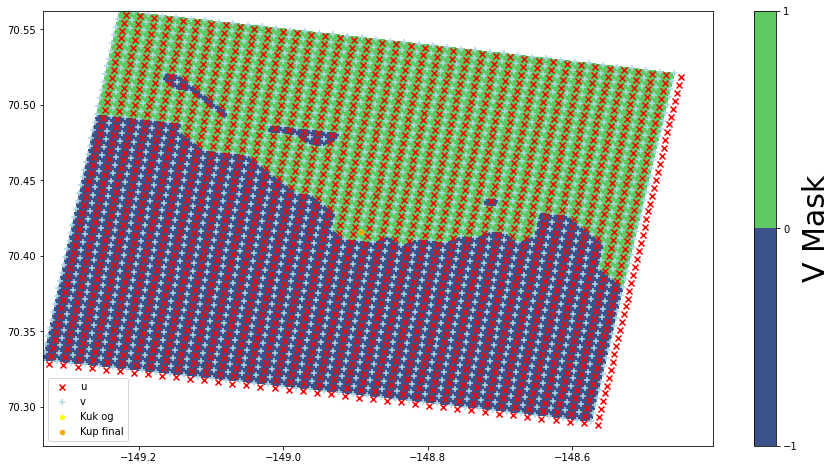

In [84]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
                    grid.lat_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
                    grid.mask_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
            grid.lat_u[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
            grid.lat_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values,
            color='lightblue', marker='+', label='v')


# Kukpuk
ax2.scatter(grid.lon_v[eta_kup_idx, xi_kup_idx].values, grid.lat_v[eta_kup_idx, xi_kup_idx].values, 
            marker='.', s=80, color='yellow', label='Kuk og')

# Point 1 - v face
eta_kup_idx_test1 = 41 #40
xi_kup_idx_test1 = 239

ax2.scatter(grid.lon_v[eta_kup_idx_test1, xi_kup_idx_test1].values, 
            grid.lat_v[eta_kup_idx_test1, xi_kup_idx_test1].values, 
            marker='.', s=80, color='orange', label='Kup final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [85]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_kup_idx_test1,xi_kup_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[11] = eta_kup_idx_test1
xi_riv_arr[11] = xi_kup_idx_test1

1.0


In [86]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_kup1 = 1

# Add this to the list 
riv_direction_arr[11] = riv_dir_kup1

In [87]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_kup1 = (river_data_kup['Discharge(m3/s)'][912:1037].values)/len_river_cells_kup

# Add this to the list 
riv_transport_arr[:,11] = Q_kup1

In [88]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_kuk = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kup = vshape_all[:, eta_kup_idx_test1, xi_kup_idx_test1]

# Add this to the array
riv_vshape_arr[:,11] = riv_vshape_kup

In [89]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_kup_tmp = river_data_kup['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kup = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_kup = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kup[:,i] = riv_temp_kup_tmp

# Add this to the array 
riv_temp_arr[:,:,11] = riv_temp_kup

In [90]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kup = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,11] = riv_salt_kup

In [91]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kuk = 10 / Q_kuk1 # when there is real data, may need one for each cell
# #riv_mud_01_kuk = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kuk = 10 / Q_kuk1 # when there is real data, may need one for each cell
# #riv_mud_02_kuk = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_kup_tmp = calc_river_ssc_Anaktuvuk(Q_kup1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_kup_tmp = calc_river_ssc_Sag_DSS3(Q_kup1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_kup_tmp = calc_river_ssc_Sag_DSS2(Q_kup1)

# Convert output from mg/L to kg/m3
riv_mud_kup = riv_mud_kup_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kup = riv_mud_kup/2
riv_mud_19_kup = riv_mud_kup/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,11] = riv_mud_01_kup

# mud 19
riv_mud_19_arr[:,11] = riv_mud_19_kup

In [92]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_kup = 0 / Q_kup1

# mud 02 
riv_mud_02_kup = 0 / Q_kup1

# mud 03
riv_mud_03_kup = 0 / Q_kup1

# mud 04
riv_mud_04_kup = 0 / Q_kup1

# mud 05
riv_mud_05_kup = 0 / Q_kup1

# mud 06
riv_mud_06_kup = 0 / Q_kup1

# mud 07
riv_mud_07_kup = 0 / Q_kup1

# mud 08
riv_mud_08_kup = 0 / Q_kup1

# mud 09
riv_mud_09_kup = 0 / Q_kup1

# mud 10
riv_mud_10_kup = 0 / Q_kup1

# mud 11
riv_mud_11_kup = 0 / Q_kup1

# mud 12
riv_mud_12_kup = 0 / Q_kup1

# mud 13
riv_mud_13_kup = 0 / Q_kup1

# mud 14
riv_mud_14_kup = 0 / Q_kup1

# mud 15
riv_mud_15_kup = 0 / Q_kup1

# mud 16
riv_mud_16_kup = 0 / Q_kup1

# mud 17
riv_mud_17_kup = 0 / Q_kup1

# mud 18
riv_mud_18_kup = 0 / Q_kup1

# mud 19
#riv_mud_19_kup = 0 / Q_kup1

# mud 20
riv_mud_20_kup = 0 / Q_kup1

# mud 21
riv_mud_21_kup = 0 / Q_kup1

# mud 22
riv_mud_22_kup = 0 / Q_kup1

# mud 23
riv_mud_23_kup = 0 / Q_kup1

# mud 24
riv_mud_24_kup = 0 / Q_kup1

# mud 25
#riv_mud_25_kup = 0 / Q_kup1

# mud 26
#riv_mud_26_kup = 0 / Q_kup1

# mud 27
#riv_mud_27_kup = 0 / Q_kup1

# mud 28
#riv_mud_28_kup = 0 / Q_kup1

# mud 29
#riv_mud_29_kup = 0 / Q_kup1

# mud 30
#riv_mud_30_kup = 0 / Q_kup1

# Save these to the arrays 
#riv_mud_01_arr[:,11] = riv_mud_01_kup

riv_mud_02_arr[:,11] = riv_mud_02_kup
riv_mud_03_arr[:,11] = riv_mud_03_kup
riv_mud_04_arr[:,11] = riv_mud_04_kup
riv_mud_05_arr[:,11] = riv_mud_05_kup
riv_mud_06_arr[:,11] = riv_mud_06_kup
riv_mud_07_arr[:,11] = riv_mud_07_kup
riv_mud_08_arr[:,11] = riv_mud_08_kup
riv_mud_09_arr[:,11] = riv_mud_09_kup
riv_mud_10_arr[:,11] = riv_mud_10_kup
riv_mud_11_arr[:,11] = riv_mud_11_kup
riv_mud_12_arr[:,11] = riv_mud_12_kup
riv_mud_13_arr[:,11] = riv_mud_13_kup
riv_mud_14_arr[:,11] = riv_mud_14_kup
riv_mud_15_arr[:,11] = riv_mud_15_kup
riv_mud_16_arr[:,11] = riv_mud_16_kup
riv_mud_17_arr[:,11] = riv_mud_17_kup
riv_mud_18_arr[:,11] = riv_mud_18_kup
#riv_mud_19_arr[:,11] = riv_mud_19_kup
riv_mud_20_arr[:,11] = riv_mud_20_kup
riv_mud_21_arr[:,11] = riv_mud_21_kup
riv_mud_22_arr[:,11] = riv_mud_22_kup
riv_mud_23_arr[:,11] = riv_mud_23_kup
riv_mud_24_arr[:,11] = riv_mud_24_kup
#riv_mud_25_arr[:,11] = riv_mud_25_kup
#riv_mud_26_arr[:,11] = riv_mud_26_kup
#riv_mud_27_arr[:,11] = riv_mud_27_kup
#riv_mud_28_arr[:,11] = riv_mud_28_kup
#riv_mud_29_arr[:,11] = riv_mud_29_kup
#riv_mud_30_arr[:,11] = riv_mud_30_kup

In [93]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_01_kuk = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_02_kuk = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_03_kuk = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,11] = riv_sand_01_kup

# sand 02
riv_sand_02_arr[:,11] = riv_sand_02_kup

# sand 03
riv_sand_03_arr[:,11] = riv_sand_03_kup

In [94]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Kukpuk
riv_id_kup = 5

# Add this to the array
riv_id_arr[11] = riv_id_kup

In [95]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kup = 3

# Add this to the array
riv_flag_arr[11] = riv_flag_kup

## Fawn Creek 
Location: 70.4099, -148.7271  
Width: 300 m  
**This river did not have data in the RADR dataset so we are ignoring this one for now**

In [96]:
# # Fawn Creek (70.4099, -148.7271), 300 m
# # Set the number of cells it will take 
# # 300 m / 750 m = ~ 1 cells
# len_river_cells_faw = 1

# # Find it manually
# eta_faw_idx = 41
# xi_faw_idx = 248

# # Needs to be on u or v point, depending what makes sense here
# print('Fawn Lat v: ', grid.lat_v[eta_faw_idx, xi_faw_idx].values)
# print('Fawn Lon v: ', grid.lon_v[eta_faw_idx, xi_faw_idx].values)

In [97]:
# # Make a plot that is a scatter plot of u and v points
# # Plot this point on the grid
# # Zoom in to see if we are in the mask
# fig2, ax2 = plt.subplots(figsize=(15,8))
# # Plot the mask
# cs2 = ax2.contourf(grid.lon_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#                     grid.lat_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#                     grid.mask_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, lev1)

# # Plot the u points
# ax2.scatter(grid.lon_u[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#             grid.lat_u[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values,
#             color='red', marker='x', label='u')

# # Plot the v points
# ax2.scatter(grid.lon_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#             grid.lat_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values,
#             color='lightblue', marker='+', label='v')


# # Fawn
# ax2.scatter(grid.lon_v[eta_faw_idx, xi_faw_idx].values, grid.lat_v[eta_faw_idx, xi_faw_idx].values, 
#             marker='.', s=80, color='yellow', label='Faw og')

# # Point 1 - v face
# eta_faw_idx_test1 = 44 #43
# xi_faw_idx_test1 = 249

# ax2.scatter(grid.lon_v[eta_faw_idx_test1, xi_faw_idx_test1].values, 
#             grid.lat_v[eta_faw_idx_test1, xi_faw_idx_test1].values, 
#             marker='.', s=80, color='orange', label='Faw final')

# ax2.legend()

# cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [98]:
# # Check that these spots are in the mask
# # Point 1 - v
# print(grid.mask_v[eta_faw_idx_test1,xi_faw_idx_test1].values)
# # If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
# eta_riv_arr[14] = eta_faw_idx_test1
# xi_riv_arr[14] = xi_faw_idx_test1

In [99]:
# # Set the river_direction
# # "river runoff grid-cell face flag"
# # where river_direction:flag_values = "0, 1, 2" 
# # river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# # Set this for each of the 5 points
# riv_dir_faw1 = 1

# # Add this to the list 
# riv_direction_arr[14] = riv_dir_faw1

In [100]:
# # Set river_transport which is the direction of the flow across the u or v face
# # This is also where we put "river runoff vertically integrated mass transport"
# # river_transport(river_time, river)

# # Make a fake time series for each point
# Q_faw1 = np.full((time_tmp_len), 1000) # m3/s


# # Add this to the list 
# riv_transport_arr[:,14] = Q_faw1

In [101]:
# # Set river_vshape
# # "sets the fractional distribution of the river_transport 
# # among the vertical cells and must sum to 1.0 over the vertical"
# # "If the river source is in shallow water several grid cells up a 
# # river tributary then a simple uniform vertical distribution 
# # (all river_Vshape values = 1/s_rho) usually works well"

# # Do uniform distribution over all depths 
# riv_vshape_faw = np.full((s_rho_len), 1/s_rho_len)

# # Add this to the array
# riv_vshape_arr[:,14] = riv_vshape_faw

In [102]:
# # Set river runoff potential temperature 
# # river_temp(river_time, s_rho, river) 
# # river_temp:long_name = "river runoff potential temperature" 
# # river_temp:units = "Celsius" 
# # river_temp:time = "river_time" 

# # This looks like it can vary vertically and can be a timeseries 
# riv_temp_faw = np.full((time_tmp_len, s_rho_len), 11)

# # Add this to the array 
# riv_temp_arr[:,:,14] = riv_temp_faw

In [103]:
# # Set the river runoff salinity
# # river_salt(river_time, s_rho, river) 
# # river_salt:long_name = "river runoff salinity" 
# # river_salt:time = "river_time"
# # units: PSS (nondimensional)

# # Just like temp, this can vary vertically and over time
# riv_salt_faw = np.full((time_tmp_len, s_rho_len), 0)

# # Add this to the array
# riv_salt_arr[:,:,14] = riv_salt_faw

In [104]:
# # Set the river mud
# # 'river_mud_'                                       ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # # for all rivers and all sediment classes
# # # mud class 01
# # riv_mud_01_faw = 10 / Q_faw1 # when there is real data, may need one for each cell
# # #riv_mud_01_faw = np.full((time_tmp_len), 0.00001)

# # # mud class 02
# # riv_mud_02_faw = 10 / Q_faw1 # when there is real data, may need one for each cell
# # #riv_mud_02_faw = np.full((time_tmp_len), 0.00001)

# # --- Lamb and Toniolo 2016 Version ---
# riv_mud_faw_tmp = calc_river_ssc(Q_faw1)
# # Convert output from mg/L to kg/m3
# riv_mud_faw = riv_mud_faw_tmp/1000

# # Divide the total river sediment discharge by two 
# # so that half belongs to each mud class
# riv_mud_01_faw = riv_mud_faw/2
# riv_mud_02_faw = riv_mud_faw/2

# # Add these to the arrays (can definitely shorten this but oh well)
# # mud 01
# riv_mud_01_arr[:,14] = riv_mud_01_faw

# # mud 02
# riv_mud_02_arr[:,14] = riv_mud_02_faw

In [105]:
# # Set the river sand
# # 'river_sand_'                                      ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # *Set all of these to 0 since sand might be too big to be carried by the river*

# # sand class 01
# riv_sand_01_faw = 0 / Q_faw1 # when there is real data, may need one for each cell
# #riv_sand_01_faw = np.full((time_tmp_len), 0.0001)

# # sand class 02
# riv_sand_02_faw = 0 / Q_faw1 # when there is real data, may need one for each cell
# #riv_sand_02_faw = np.full((time_tmp_len), 0.0001)

# # Add this to the array
# # sand 01 
# riv_sand_01_arr[:,14] = riv_sand_01_faw

# # sand 02
# riv_sand_02_arr[:,14] = riv_sand_02_faw

In [106]:
# # Set the river id number
# # This number will match the one in the info for the netcdf
# # Fawn
# riv_id_faw = 8

# # Add this to the array
# riv_id_arr[14] = riv_id_faw

In [107]:
# # Set the river flag ('river runoff tracer flag')
# # rdir.flag_values = '0, 1, 2, 3'
# # rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# # only salinity is on, both temperature and salinity are on'
# riv_flag_faw = 3

# # Add this to the array
# riv_flag_arr[14] = riv_flag_faw

## Putuligayuk River 
Location: 70.3113, -148.4792  
Width: 409 m  
This river has been commented out since it is so small and not in the Blaskey data.

In [108]:
# # Putuligayuk River (70.3113, -148.4792), 409 m
# # Set the number of cells it will take 
# # 409 m / 750 m = ~ 1 cells
# len_river_cells_put = 1

# # Find it manually
# eta_put_idx = 26
# xi_put_idx = 263

# # Needs to be on u or v point, depending what makes sense here
# print('Putuligayuk Lat v: ', grid.lat_v[eta_put_idx, xi_put_idx].values)
# print('Putuligayuk Lon v: ', grid.lon_v[eta_put_idx, xi_put_idx].values)

In [109]:
# # Make a plot that is a scatter plot of u and v points
# # Plot this point on the grid
# # Zoom in to see if we are in the mask
# fig2, ax2 = plt.subplots(figsize=(15,8))
# # Plot the mask
# cs2 = ax2.contourf(grid.lon_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
#                     grid.lat_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
#                     grid.mask_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, lev1)

# # Plot the u points
# ax2.scatter(grid.lon_u[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
#             grid.lat_u[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values,
#             color='red', marker='x', label='u')

# # Plot the v points
# ax2.scatter(grid.lon_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
#             grid.lat_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values,
#             color='lightblue', marker='+', label='v')


# # Putuligayuk
# ax2.scatter(grid.lon_v[eta_put_idx, xi_put_idx].values, grid.lat_v[eta_put_idx, xi_put_idx].values, 
#             marker='.', s=80, color='yellow', label='Put og')

# # Point 1 - v face
# eta_put_idx_test1 = 28 #27
# xi_put_idx_test1 = 264

# ax2.scatter(grid.lon_v[eta_put_idx_test1, xi_put_idx_test1].values, 
#             grid.lat_v[eta_put_idx_test1, xi_put_idx_test1].values, 
#             marker='.', s=80, color='orange', label='Put final')

# ax2.legend()

# cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [110]:
# # Check that these spots are in the mask
# # Point 1 - v
# print(grid.mask_v[eta_put_idx_test1,xi_put_idx_test1].values)
# # If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
# eta_riv_arr[13] = eta_put_idx_test1
# xi_riv_arr[13] = xi_put_idx_test1

In [111]:
# # Set the river_direction
# # "river runoff grid-cell face flag"
# # where river_direction:flag_values = "0, 1, 2" 
# # river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# # Set this for each of the 5 points
# riv_dir_put1 = 1

# # Add this to the list 
# riv_direction_arr[13] = riv_dir_put1

In [112]:
# # Set river_transport which is the direction of the flow across the u or v face
# # This is also where we put "river runoff vertically integrated mass transport"
# # river_transport(river_time, river)

# # Use Blaskey data
# Q_put1 = (river_data_put['Discharge(m3/s)'][912:1037].values)/len_river_cells_put

# # Add this to the list 
# riv_transport_arr[:,13] = Q_put1

In [113]:
# # Set river_vshape
# # "sets the fractional distribution of the river_transport 
# # among the vertical cells and must sum to 1.0 over the vertical"
# # "If the river source is in shallow water several grid cells up a 
# # river tributary then a simple uniform vertical distribution 
# # (all river_Vshape values = 1/s_rho) usually works well"

# # Do uniform distribution over all depths 
# #riv_vshape_put = np.full((s_rho_len), 1/s_rho_len)

# # Read in the vshape for this cell
# # Use the indices from above - these are u/v indices but v_shape 
# # is n terms of rho indices but hopefully they are close enough 
# # that it doesn't matter too much but keep note of this 
# riv_vshape_put = vshape_all[:, eta_put_idx_test1, xi_put_idx_test1]

# # Add this to the array
# riv_vshape_arr[:,13] = riv_vshape_put

In [114]:
# # Set river runoff potential temperature 
# # river_temp(river_time, s_rho, river) 
# # river_temp:long_name = "river runoff potential temperature" 
# # river_temp:units = "Celsius" 
# # river_temp:time = "river_time" 

# # Read in river temperature from Blaskey data
# riv_temp_put_tmp = river_data_put['WaterTemp(C)'][912:1037].values

# # This looks like it can vary vertically and can be a timeseries 
# #riv_temp_put = np.full((time_tmp_len, s_rho_len), 11)
# # Make this the same in each layer 
# riv_temp_put = np.empty((time_tmp_len, s_rho_len))
# for i in range(s_rho_len):
#     riv_temp_put[:,i] = riv_temp_put_tmp

# # Add this to the array 
# riv_temp_arr[:,:,13] = riv_temp_put

In [115]:
# # Set the river runoff salinity
# # river_salt(river_time, s_rho, river) 
# # river_salt:long_name = "river runoff salinity" 
# # river_salt:time = "river_time"
# # units: PSS (nondimensional)

# # Just like temp, this can vary vertically and over time
# riv_salt_put = np.full((time_tmp_len, s_rho_len), 0)

# # Add this to the array
# riv_salt_arr[:,:,13] = riv_salt_put

In [116]:
# # Set the river mud
# # 'river_mud_'                                       ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # # for all rivers and all sediment classes
# # # mud class 01
# # riv_mud_01_put = 10 / Q_put1 # when there is real data, may need one for each cell
# # #riv_mud_01_put = np.full((time_tmp_len), 0.00001)

# # # mud class 02
# # riv_mud_02_put = 10 / Q_put1 # when there is real data, may need one for each cell
# # #riv_mud_02_put = np.full((time_tmp_len), 0.00001)

# # --- Lamb and Toniolo 2016 Version ---
# #riv_mud_put_tmp = calc_river_ssc_Anaktuvuk(Q_put1)
# # --- Toniolo et al. 2024 version DSS3 --- 
# riv_mud_put_tmp = calc_river_ssc_Sag_DSS3(Q_put1)
# # --- Toniolo et al. 2024 version DSS2 --- 
# #riv_mud_put_tmp = calc_river_ssc_Sag_DSS2(Q_put1)

# # Convert output from mg/L to kg/m3
# riv_mud_put = riv_mud_put_tmp/1000

# # Divide the total river sediment discharge by two 
# # so that half belongs to each mud class
# riv_mud_01_put = riv_mud_put/2
# riv_mud_21_put = riv_mud_put/2

# # Add these to the arrays (can definitely shorten this but oh well)
# # mud 01
# riv_mud_01_arr[:,13] = riv_mud_01_put

# # mud 21
# riv_mud_21_arr[:,13] = riv_mud_21_put

In [117]:
# # Set all the other mud classes to 0 for this river 

# # mud 01
# #riv_mud_01_put = 0 / Q_put1

# # mud 02 
# riv_mud_02_put = 0 / Q_put1

# # mud 03
# riv_mud_03_put = 0 / Q_put1

# # mud 04
# riv_mud_04_put = 0 / Q_put1

# # mud 05
# riv_mud_05_put = 0 / Q_put1

# # mud 06
# riv_mud_06_put = 0 / Q_put1

# # mud 07
# riv_mud_07_put = 0 / Q_put1

# # mud 08
# riv_mud_08_put = 0 / Q_put1

# # mud 09
# riv_mud_09_put = 0 / Q_put1

# # mud 10
# riv_mud_10_put = 0 / Q_put1

# # mud 11
# riv_mud_11_put = 0 / Q_put1

# # mud 12
# riv_mud_12_put = 0 / Q_put1

# # mud 13
# riv_mud_13_put = 0 / Q_put1

# # mud 14
# riv_mud_14_put = 0 / Q_put1

# # mud 15
# riv_mud_15_put = 0 / Q_put1

# # mud 16
# riv_mud_16_put = 0 / Q_put1

# # mud 17
# riv_mud_17_put = 0 / Q_put1

# # mud 18
# riv_mud_18_put = 0 / Q_put1

# # mud 19
# riv_mud_19_put = 0 / Q_put1

# # mud 20
# riv_mud_20_put = 0 / Q_put1

# # mud 21
# #riv_mud_21_put = 0 / Q_put1

# # mud 22
# riv_mud_22_put = 0 / Q_put1

# # mud 23
# riv_mud_23_put = 0 / Q_put1

# # mud 24
# riv_mud_24_put = 0 / Q_put1

# # mud 25
# riv_mud_25_put = 0 / Q_put1

# # mud 26
# riv_mud_26_put = 0 / Q_put1

# # mud 27
# riv_mud_27_put = 0 / Q_put1

# # mud 28
# #riv_mud_28_put = 0 / Q_put1

# # mud 29
# #riv_mud_29_put = 0 / Q_put1

# # mud 30
# #riv_mud_30_put = 0 / Q_put1

# # Save these to the arrays 
# #riv_mud_01_arr[:,14] = riv_mud_01_put

# riv_mud_02_arr[:,13] = riv_mud_02_put
# riv_mud_03_arr[:,13] = riv_mud_03_put
# riv_mud_04_arr[:,13] = riv_mud_04_put
# riv_mud_05_arr[:,13] = riv_mud_05_put
# riv_mud_06_arr[:,13] = riv_mud_06_put
# riv_mud_07_arr[:,13] = riv_mud_07_put
# riv_mud_08_arr[:,13] = riv_mud_08_put
# riv_mud_09_arr[:,13] = riv_mud_09_put
# riv_mud_10_arr[:,13] = riv_mud_10_put
# riv_mud_11_arr[:,13] = riv_mud_11_put
# riv_mud_12_arr[:,13] = riv_mud_12_put
# riv_mud_13_arr[:,13] = riv_mud_13_put
# riv_mud_14_arr[:,13] = riv_mud_14_put
# riv_mud_15_arr[:,13] = riv_mud_15_put
# riv_mud_16_arr[:,13] = riv_mud_16_put
# riv_mud_17_arr[:,13] = riv_mud_17_put
# riv_mud_18_arr[:,13] = riv_mud_18_put
# riv_mud_19_arr[:,13] = riv_mud_19_put
# riv_mud_20_arr[:,13] = riv_mud_20_put
# #riv_mud_21_arr[:,13] = riv_mud_21_put
# riv_mud_22_arr[:,13] = riv_mud_22_put
# riv_mud_23_arr[:,13] = riv_mud_23_put
# riv_mud_24_arr[:,13] = riv_mud_24_put
# riv_mud_25_arr[:,13] = riv_mud_25_put
# riv_mud_26_arr[:,13] = riv_mud_26_put
# riv_mud_27_arr[:,13] = riv_mud_27_put
# #riv_mud_28_arr[:,13] = riv_mud_28_put
# #riv_mud_29_arr[:,13] = riv_mud_29_put
# #riv_mud_30_arr[:,13] = riv_mud_30_put

In [118]:
# # Set the river sand
# # 'river_sand_'                                      ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # *Set all of these to 0 since sand might be too big to be carried by the river*

# # sand class 01
# riv_sand_01_put = 0 / Q_put1 # when there is real data, may need one for each cell
# #riv_sand_01_put = np.full((time_tmp_len), 0.0001)

# # sand class 02
# riv_sand_02_put = 0 / Q_put1 # when there is real data, may need one for each cell
# #riv_sand_02_put = np.full((time_tmp_len), 0.0001)

# # sand class 03
# riv_sand_03_put = 0 / Q_put1 # when there is real data, may need one for each cell
# #riv_sand_03_put = np.full((time_tmp_len), 0.0)

# # Add this to the array
# # sand 01 
# riv_sand_01_arr[:,13] = riv_sand_01_put

# # sand 02
# riv_sand_02_arr[:,13] = riv_sand_02_put

# # sand 03
# riv_sand_03_arr[:,13] = riv_sand_03_put

In [119]:
# # Set the river id number
# # This number will match the one in the info for the netcdf
# # Fawn
# riv_id_put = 7 #9

# # Add this to the array
# riv_id_arr[13] = riv_id_put

In [120]:
# # Set the river flag ('river runoff tracer flag')
# # rdir.flag_values = '0, 1, 2, 3'
# # rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# # only salinity is on, both temperature and salinity are on'
# riv_flag_put = 3

# # Add this to the array
# riv_flag_arr[13] = riv_flag_put

## Canning River (splits into two neat coast):  
### Staines River   
Location: 70.1419, -145.9989  
Width: 892.9 m

In [121]:
# Staines River (70.1419, -145.9989), 892.9 m
# Set the number of cells it will take 
# 892.9 m / 750 m = ~ 1 cells
len_river_cells_sta = 1

# Find it manually
eta_sta_idx = 24
xi_sta_idx = 392

# Needs to be on u or v point, depending what makes sense here
print('Staines Lat v: ', grid.lat_v[eta_sta_idx, xi_sta_idx].values)
print('Staines Lon v: ', grid.lon_v[eta_sta_idx, xi_sta_idx].values)

Staines Lat v:  70.14066729098846
Staines Lon v:  -145.98518822035305


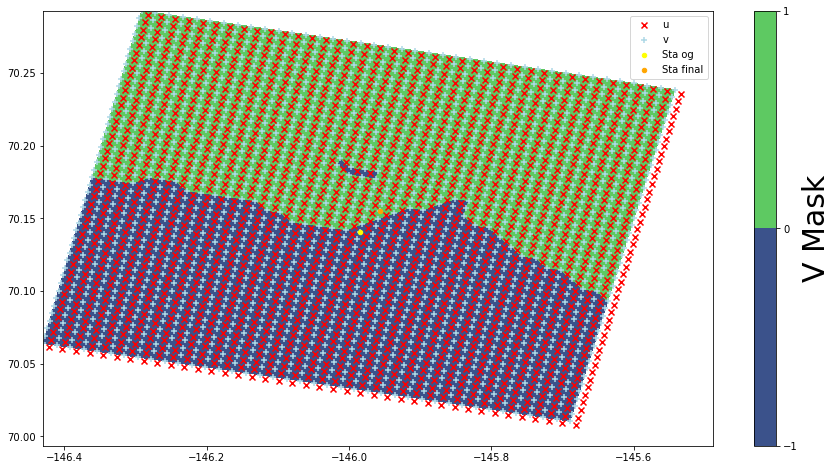

In [122]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
                    grid.lat_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
                    grid.mask_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
            grid.lat_u[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
            grid.lat_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values,
            color='lightblue', marker='+', label='v')


# Staines
ax2.scatter(grid.lon_v[eta_sta_idx, xi_sta_idx].values, grid.lat_v[eta_sta_idx, xi_sta_idx].values, 
            marker='.', s=80, color='yellow', label='Sta og')

# Point 1 - v face
eta_sta_idx_test1 = 27 #26
xi_sta_idx_test1 = 393

ax2.scatter(grid.lon_v[eta_sta_idx_test1, xi_sta_idx_test1].values, 
            grid.lat_v[eta_sta_idx_test1, xi_sta_idx_test1].values, 
            marker='.', s=80, color='orange', label='Sta final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [123]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_sta_idx_test1,xi_sta_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[12] = eta_sta_idx_test1
xi_riv_arr[12] = xi_sta_idx_test1

1.0


In [124]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sta1 = 1

# Add this to the list 
riv_direction_arr[12] = riv_dir_sta1

In [125]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_sta1 = (river_data_sta['Discharge(m3/s)'][912:1037].values)/len_river_cells_sta

# Add this to the list 
riv_transport_arr[:,12] = Q_sta1

In [126]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sta = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sta = vshape_all[:, eta_sta_idx_test1, xi_sta_idx_test1]

# Add this to the array
riv_vshape_arr[:,12] = riv_vshape_sta

In [127]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_sta_tmp = river_data_sta['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sta = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sta = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sta[:,i] = riv_temp_sta_tmp

# Add this to the array 
riv_temp_arr[:,:,12] = riv_temp_sta

In [128]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sta = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,12] = riv_salt_sta

In [129]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sta = 10 / Q_sta1 # when there is real data, may need one for each cell
# #riv_mud_01_sta = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sta = 10 / Q_sta1 # when there is real data, may need one for each cell
# #riv_mud_02_sta = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_sta_tmp = calc_river_ssc_Anaktuvuk(Q_sta1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_sta_tmp = calc_river_ssc_Sag_DSS3(Q_sta1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_sta_tmp = calc_river_ssc_Sag_DSS2(Q_sta1)

# Convert output from mg/L to kg/m3
riv_mud_sta = riv_mud_sta_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sta = riv_mud_sta/2
riv_mud_20_sta = riv_mud_sta/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,12] = riv_mud_01_sta

# mud 20
riv_mud_20_arr[:,12] = riv_mud_20_sta

In [130]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_sta = 0 / Q_sta1

# mud 02 
riv_mud_02_sta = 0 / Q_sta1

# mud 03
riv_mud_03_sta = 0 / Q_sta1

# mud 04
riv_mud_04_sta = 0 / Q_sta1

# mud 05
riv_mud_05_sta = 0 / Q_sta1

# mud 06
riv_mud_06_sta = 0 / Q_sta1

# mud 07
riv_mud_07_sta = 0 / Q_sta1

# mud 08
riv_mud_08_sta = 0 / Q_sta1

# mud 09
riv_mud_09_sta = 0 / Q_sta1

# mud 10
riv_mud_10_sta = 0 / Q_sta1

# mud 11
riv_mud_11_sta = 0 / Q_sta1

# mud 12
riv_mud_12_sta = 0 / Q_sta1

# mud 13
riv_mud_13_sta = 0 / Q_sta1

# mud 14
riv_mud_14_sta = 0 / Q_sta1

# mud 15
riv_mud_15_sta = 0 / Q_sta1

# mud 16
riv_mud_16_sta = 0 / Q_sta1

# mud 17
riv_mud_17_sta = 0 / Q_sta1

# mud 18
riv_mud_18_sta = 0 / Q_sta1

# mud 19
riv_mud_19_sta = 0 / Q_sta1

# mud 20
#riv_mud_20_sta = 0 / Q_sta1

# mud 21
riv_mud_21_sta = 0 / Q_sta1

# mud 22
riv_mud_22_sta = 0 / Q_sta1

# mud 23
riv_mud_23_sta = 0 / Q_sta1

# mud 24
riv_mud_24_sta = 0 / Q_sta1

# mud 25
#riv_mud_25_sta = 0 / Q_sta1

# mud 26
#riv_mud_26_sta = 0 / Q_sta1

# mud 27
#riv_mud_27_sta = 0 / Q_sta1

# mud 28
#riv_mud_28_sta = 0 / Q_sta1

# mud 29
#riv_mud_29_sta = 0 / Q_sta1

# mud 30
#riv_mud_30_sta = 0 / Q_sta1

# Save these to the arrays 
#riv_mud_01_arr[:,12] = riv_mud_01_sta

riv_mud_02_arr[:,12] = riv_mud_02_sta
riv_mud_03_arr[:,12] = riv_mud_03_sta
riv_mud_04_arr[:,12] = riv_mud_04_sta
riv_mud_05_arr[:,12] = riv_mud_05_sta
riv_mud_06_arr[:,12] = riv_mud_06_sta
riv_mud_07_arr[:,12] = riv_mud_07_sta
riv_mud_08_arr[:,12] = riv_mud_08_sta
riv_mud_09_arr[:,12] = riv_mud_09_sta
riv_mud_10_arr[:,12] = riv_mud_10_sta
riv_mud_11_arr[:,12] = riv_mud_11_sta
riv_mud_12_arr[:,12] = riv_mud_12_sta
riv_mud_13_arr[:,12] = riv_mud_13_sta
riv_mud_14_arr[:,12] = riv_mud_14_sta
riv_mud_15_arr[:,12] = riv_mud_15_sta
riv_mud_16_arr[:,12] = riv_mud_16_sta
riv_mud_17_arr[:,12] = riv_mud_17_sta
riv_mud_18_arr[:,12] = riv_mud_18_sta
riv_mud_19_arr[:,12] = riv_mud_19_sta
#riv_mud_20_arr[:,12] = riv_mud_20_sta
riv_mud_21_arr[:,12] = riv_mud_21_sta
riv_mud_22_arr[:,12] = riv_mud_22_sta
riv_mud_23_arr[:,12] = riv_mud_23_sta
riv_mud_24_arr[:,12] = riv_mud_24_sta
#riv_mud_25_arr[:,12] = riv_mud_25_sta
#riv_mud_26_arr[:,12] = riv_mud_26_sta
#riv_mud_27_arr[:,12] = riv_mud_27_sta
#riv_mud_28_arr[:,12] = riv_mud_28_sta
#riv_mud_29_arr[:,12] = riv_mud_29_sta
#riv_mud_30_arr[:,12] = riv_mud_30_sta

In [131]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_01_sta = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_02_sta = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_03_sta = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,12] = riv_sand_01_sta

# sand 02
riv_sand_02_arr[:,12] = riv_sand_02_sta

# sand 03
riv_sand_03_arr[:,12] = riv_sand_03_sta

In [132]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_sta = 6 #10

# Add this to the array
riv_id_arr[12] = riv_id_sta

In [133]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_sta = 3

# Add this to the array
riv_flag_arr[12] = riv_flag_sta

### Canning River  
Location: 70.061, -145.5553  
Width: 1070 m

In [134]:
# Canning River (70.061, -145.5553), 1070 m
# Set the number of cells it will take 
# 1070 m / 750 m = 1.43 ~ 1 cells
len_river_cells_can = 1

# Find it manually
eta_can_idx = 15
xi_can_idx = 416

# Needs to be on u or v point, depending what makes sense here
print('Canning Lat v: ', grid.lat_v[eta_can_idx, xi_can_idx].values)
print('Canning Lon v: ', grid.lon_v[eta_can_idx, xi_can_idx].values)

Canning Lat v:  70.06024972504456
Canning Lon v:  -145.55802030929465


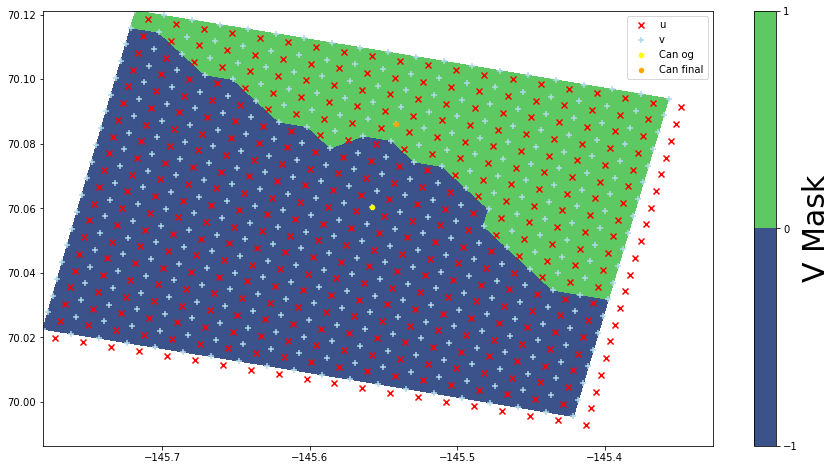

In [135]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
                    grid.lat_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
                    grid.mask_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
            grid.lat_u[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
            grid.lat_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values,
            color='lightblue', marker='+', label='v')


# Canning
ax2.scatter(grid.lon_v[eta_can_idx, xi_can_idx].values, grid.lat_v[eta_can_idx, xi_can_idx].values, 
            marker='.', s=80, color='yellow', label='Can og')

# Point 1 - v face
eta_can_idx_test1 = 20 #19
xi_can_idx_test1 = 416

ax2.scatter(grid.lon_v[eta_can_idx_test1, xi_can_idx_test1].values, 
            grid.lat_v[eta_can_idx_test1, xi_can_idx_test1].values, 
            marker='.', s=80, color='orange', label='Can final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [136]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_can_idx_test1,xi_can_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[13] = eta_can_idx_test1
xi_riv_arr[13] = xi_can_idx_test1

1.0


In [137]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_can1 = 1

# Add this to the list 
riv_direction_arr[13] = riv_dir_can1

In [138]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_can1 = (river_data_can['Discharge(m3/s)'][912:1037].values)/len_river_cells_can

# Add this to the list 
riv_transport_arr[:,13] = Q_can1

In [139]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_can = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_can = vshape_all[:, eta_can_idx_test1, xi_can_idx_test1]

# Add this to the array
riv_vshape_arr[:,13] = riv_vshape_can

In [140]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_can_tmp = river_data_can['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_can = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_can = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_can[:,i] = riv_temp_can_tmp

# Add this to the array 
riv_temp_arr[:,:,13] = riv_temp_can

In [141]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_can = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,13] = riv_salt_can

In [142]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_can = 10 / Q_can1 # when there is real data, may need one for each cell
# #riv_mud_01_can = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_can = 10 / Q_can1 # when there is real data, may need one for each cell
# #riv_mud_02_can = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_can_tmp = calc_river_ssc_Anaktuvuk(Q_can1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_can_tmp = calc_river_ssc_Sag_DSS3(Q_can1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_can_tmp = calc_river_ssc_Sag_DSS2(Q_can1)

# Convert output from mg/L to kg/m3
riv_mud_can = riv_mud_can_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_can = riv_mud_can/2
riv_mud_21_can = riv_mud_can/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,13] = riv_mud_01_can

# mud 21
riv_mud_21_arr[:,13] = riv_mud_21_can

In [143]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_can = 0 / Q_can1

# mud 02 
riv_mud_02_can = 0 / Q_can1

# mud 03
riv_mud_03_can = 0 / Q_can1

# mud 04
riv_mud_04_can = 0 / Q_can1

# mud 05
riv_mud_05_can = 0 / Q_can1

# mud 06
riv_mud_06_can = 0 / Q_can1

# mud 07
riv_mud_07_can = 0 / Q_can1

# mud 08
riv_mud_08_can = 0 / Q_can1

# mud 09
riv_mud_09_can = 0 / Q_can1

# mud 10
riv_mud_10_can = 0 / Q_can1

# mud 11
riv_mud_11_can = 0 / Q_can1

# mud 12
riv_mud_12_can = 0 / Q_can1

# mud 13
riv_mud_13_can = 0 / Q_can1

# mud 14
riv_mud_14_can = 0 / Q_can1

# mud 15
riv_mud_15_can = 0 / Q_can1

# mud 16
riv_mud_16_can = 0 / Q_can1

# mud 17
riv_mud_17_can = 0 / Q_can1

# mud 18
riv_mud_18_can = 0 / Q_can1

# mud 19
riv_mud_19_can = 0 / Q_can1

# mud 20
riv_mud_20_can = 0 / Q_can1

# mud 21
#riv_mud_21_can = 0 / Q_can1

# mud 22
riv_mud_22_can = 0 / Q_can1

# mud 23
riv_mud_23_can = 0 / Q_can1

# mud 24
riv_mud_24_can = 0 / Q_can1

# mud 25
#riv_mud_25_can = 0 / Q_can1

# mud 26
#riv_mud_26_can = 0 / Q_can1

# mud 27
#riv_mud_27_can = 0 / Q_can1

# mud 28
#riv_mud_28_can = 0 / Q_can1

# mud 29
#riv_mud_29_can = 0 / Q_can1

# mud 30
#riv_mud_30_can = 0 / Q_can1

# Save these to the arrays 
#riv_mud_01_arr[:,13] = riv_mud_01_can

riv_mud_02_arr[:,13] = riv_mud_02_can
riv_mud_03_arr[:,13] = riv_mud_03_can
riv_mud_04_arr[:,13] = riv_mud_04_can
riv_mud_05_arr[:,13] = riv_mud_05_can
riv_mud_06_arr[:,13] = riv_mud_06_can
riv_mud_07_arr[:,13] = riv_mud_07_can
riv_mud_08_arr[:,13] = riv_mud_08_can
riv_mud_09_arr[:,13] = riv_mud_09_can
riv_mud_10_arr[:,13] = riv_mud_10_can
riv_mud_11_arr[:,13] = riv_mud_11_can
riv_mud_12_arr[:,13] = riv_mud_12_can
riv_mud_13_arr[:,13] = riv_mud_13_can
riv_mud_14_arr[:,13] = riv_mud_14_can
riv_mud_15_arr[:,13] = riv_mud_15_can
riv_mud_16_arr[:,13] = riv_mud_16_can
riv_mud_17_arr[:,13] = riv_mud_17_can
riv_mud_18_arr[:,13] = riv_mud_18_can
riv_mud_19_arr[:,13] = riv_mud_19_can
riv_mud_20_arr[:,13] = riv_mud_20_can
#riv_mud_21_arr[:,13] = riv_mud_21_can
riv_mud_22_arr[:,13] = riv_mud_22_can
riv_mud_23_arr[:,13] = riv_mud_23_can
riv_mud_24_arr[:,13] = riv_mud_24_can
#riv_mud_25_arr[:,13] = riv_mud_25_can
#riv_mud_26_arr[:,13] = riv_mud_26_can
#riv_mud_27_arr[:,13] = riv_mud_27_can
#riv_mud_28_arr[:,13] = riv_mud_28_can
#riv_mud_29_arr[:,13] = riv_mud_29_can
#riv_mud_30_arr[:,13] = riv_mud_30_can

In [144]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_01_can = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_02_can = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_03_can = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,13] = riv_sand_01_can

# sand 02
riv_sand_02_arr[:,13] = riv_sand_02_can

# sand 03
riv_sand_03_arr[:,13] = riv_sand_03_can

In [145]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_can = 7 #11

# Add this to the array
riv_id_arr[13] = riv_id_can

In [146]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_can = 3

# Add this to the array
riv_flag_arr[13] = riv_flag_can

## Katakturuk River (splits into two near coast but keeps the same name; using only the larger one):  
Location: 69.976, -144.9958  
Width: 265 m

In [147]:
# Katakturuk River (69.976, -144.9958), 265 m
# Set the number of cells it will take 
# 265 m / 750 m = ~ 1 cells
len_river_cells_kat = 1

# Find it manually
eta_kat_idx = 7
xi_kat_idx = 447

# Needs to be on u or v point, depending what makes sense here
print('Katakturuk Lat v: ', grid.lat_v[eta_kat_idx, xi_kat_idx].values)
print('Katakturuk Lon v: ', grid.lon_v[eta_kat_idx, xi_kat_idx].values)

Katakturuk Lat v:  69.9735534947528
Katakturuk Lon v:  -144.99886088516104


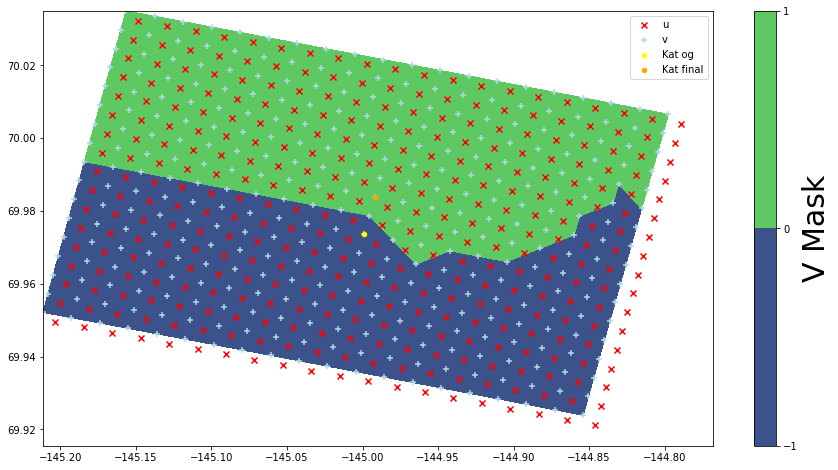

In [148]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
                    grid.lat_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
                    grid.mask_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
            grid.lat_u[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
            grid.lat_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values,
            color='lightblue', marker='+', label='v')


# Katakturuk
ax2.scatter(grid.lon_v[eta_kat_idx, xi_kat_idx].values, grid.lat_v[eta_kat_idx, xi_kat_idx].values, 
            marker='.', s=80, color='yellow', label='Kat og')

# Point 1 - v face
eta_kat_idx_test1 = 9 #8
xi_kat_idx_test1 = 447

ax2.scatter(grid.lon_v[eta_kat_idx_test1, xi_kat_idx_test1].values, 
            grid.lat_v[eta_kat_idx_test1, xi_kat_idx_test1].values, 
            marker='.', s=80, color='orange', label='Kat final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [149]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_kat_idx_test1,xi_kat_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[14] = eta_kat_idx_test1
xi_riv_arr[14] = xi_kat_idx_test1

1.0


In [150]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_kat1 = 1

# Add this to the list 
riv_direction_arr[14] = riv_dir_kat1

In [151]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_kat1 = (river_data_kat['Discharge(m3/s)'][912:1037].values)/len_river_cells_kat

# Add this to the list 
riv_transport_arr[:,14] = Q_kat1

In [152]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_kat = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kat = vshape_all[:, eta_kat_idx_test1, xi_kat_idx_test1]

# Add this to the array
riv_vshape_arr[:,14] = riv_vshape_kat

In [153]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_kat_tmp = river_data_kat['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kat = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_kat = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kat[:,i] = riv_temp_kat_tmp

# Add this to the array 
riv_temp_arr[:,:,14] = riv_temp_kat

In [154]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kat = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,14] = riv_salt_kat

In [155]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kat = 10 / Q_kat1 # when there is real data, may need one for each cell
# #riv_mud_01_kat = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kat = 10 / Q_kat1 # when there is real data, may need one for each cell
# #riv_mud_02_kat = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_kat_tmp = calc_river_ssc(Q_kat1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_kat_tmp = calc_river_ssc_Sag_DSS3(Q_kat1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_kat_tmp = calc_river_ssc_Sag_DSS2(Q_kat1)

# Convert output from mg/L to kg/m3
riv_mud_kat = riv_mud_kat_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kat = riv_mud_kat/2
riv_mud_22_kat = riv_mud_kat/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,14] = riv_mud_01_kat

# mud 22
riv_mud_22_arr[:,14] = riv_mud_22_kat

In [156]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_kat = 0 / Q_kat1

# mud 02 
riv_mud_02_kat = 0 / Q_kat1

# mud 03
riv_mud_03_kat = 0 / Q_kat1

# mud 04
riv_mud_04_kat = 0 / Q_kat1

# mud 05
riv_mud_05_kat = 0 / Q_kat1

# mud 06
riv_mud_06_kat = 0 / Q_kat1

# mud 07
riv_mud_07_kat = 0 / Q_kat1

# mud 08
riv_mud_08_kat = 0 / Q_kat1

# mud 09
riv_mud_09_kat = 0 / Q_kat1

# mud 10
riv_mud_10_kat = 0 / Q_kat1

# mud 11
riv_mud_11_kat = 0 / Q_kat1

# mud 12
riv_mud_12_kat = 0 / Q_kat1

# mud 13
riv_mud_13_kat = 0 / Q_kat1

# mud 14
riv_mud_14_kat = 0 / Q_kat1

# mud 15
riv_mud_15_kat = 0 / Q_kat1

# mud 16
riv_mud_16_kat = 0 / Q_kat1

# mud 17
riv_mud_17_kat = 0 / Q_kat1

# mud 18
riv_mud_18_kat = 0 / Q_kat1

# mud 19
riv_mud_19_kat = 0 / Q_kat1

# mud 20
riv_mud_20_kat = 0 / Q_kat1

# mud 21
riv_mud_21_kat = 0 / Q_kat1

# mud 22
#riv_mud_22_kat = 0 / Q_kat1

# mud 23
riv_mud_23_kat = 0 / Q_kat1

# mud 24
riv_mud_24_kat = 0 / Q_kat1

# mud 25
#riv_mud_25_kat = 0 / Q_kat1

# mud 26
#riv_mud_26_kat = 0 / Q_kat1

# mud 27
#riv_mud_27_kat = 0 / Q_kat1

# mud 28
#riv_mud_28_kat = 0 / Q_kat1

# mud 29
#riv_mud_29_kat = 0 / Q_kat1

# mud 30
#riv_mud_30_kat = 0 / Q_kat1

# Save these to the arrays 
#riv_mud_01_arr[:,14] = riv_mud_01_kat

riv_mud_02_arr[:,14] = riv_mud_02_kat
riv_mud_03_arr[:,14] = riv_mud_03_kat
riv_mud_04_arr[:,14] = riv_mud_04_kat
riv_mud_05_arr[:,14] = riv_mud_05_kat
riv_mud_06_arr[:,14] = riv_mud_06_kat
riv_mud_07_arr[:,14] = riv_mud_07_kat
riv_mud_08_arr[:,14] = riv_mud_08_kat
riv_mud_09_arr[:,14] = riv_mud_09_kat
riv_mud_10_arr[:,14] = riv_mud_10_kat
riv_mud_11_arr[:,14] = riv_mud_11_kat
riv_mud_12_arr[:,14] = riv_mud_12_kat
riv_mud_13_arr[:,14] = riv_mud_13_kat
riv_mud_14_arr[:,14] = riv_mud_14_kat
riv_mud_15_arr[:,14] = riv_mud_15_kat
riv_mud_16_arr[:,14] = riv_mud_16_kat
riv_mud_17_arr[:,14] = riv_mud_17_kat
riv_mud_18_arr[:,14] = riv_mud_18_kat
riv_mud_19_arr[:,14] = riv_mud_19_kat
riv_mud_20_arr[:,14] = riv_mud_20_kat
riv_mud_21_arr[:,14] = riv_mud_21_kat
#riv_mud_22_arr[:,14] = riv_mud_22_kat
riv_mud_23_arr[:,14] = riv_mud_23_kat
riv_mud_24_arr[:,14] = riv_mud_24_kat
#riv_mud_25_arr[:,14] = riv_mud_25_kat
#riv_mud_26_arr[:,14] = riv_mud_26_kat
#riv_mud_27_arr[:,14] = riv_mud_27_kat
#riv_mud_28_arr[:,14] = riv_mud_28_kat
#riv_mud_29_arr[:,14] = riv_mud_29_kat
#riv_mud_30_arr[:,14] = riv_mud_30_kat

In [157]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_01_kat = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_02_kat = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_03_kat = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,14] = riv_sand_01_kat

# sand 02
riv_sand_02_arr[:,14] = riv_sand_02_kat

# sand 03
riv_sand_03_arr[:,14] = riv_sand_03_kat

In [158]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_kat = 8 #12

# Add this to the array
riv_id_arr[14] = riv_id_kat

In [159]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kat = 3

# Add this to the array
riv_flag_arr[14] = riv_flag_kat

## Hulahula River
Location: 70.0654, -144.085  
Width: 790 m

In [160]:
# Hulahula River (70.0654, -144.085), 790 m
# Set the number of cells it will take 
# 790 m / 750 m = ~ 1 cells
len_river_cells_hul = 1

# Find it manually
eta_hul_idx = 38
xi_hul_idx = 489

# Needs to be on u or v point, depending what makes sense here
print('Hulahula Lat u: ', grid.lat_u[eta_hul_idx, xi_hul_idx].values)
print('Hulahula Lon u: ', grid.lon_u[eta_hul_idx, xi_hul_idx].values)

Hulahula Lat u:  70.06600462697061
Hulahula Lon u:  -144.08646759670745


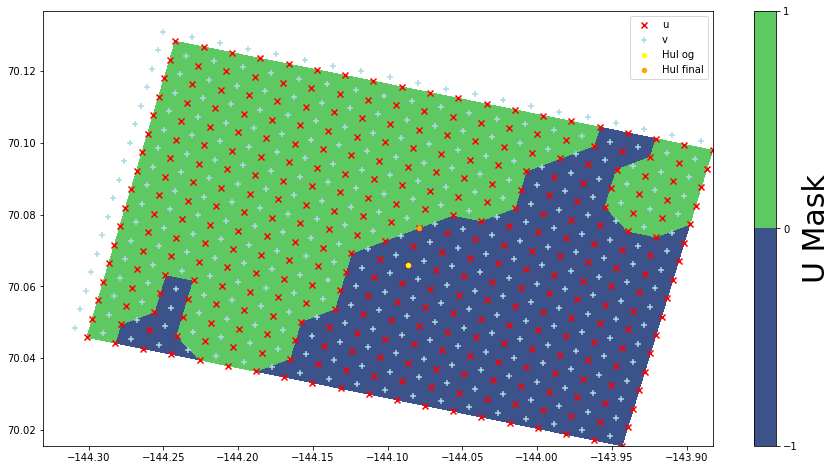

In [161]:
# ORIGINAL - IN MASK
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.mask_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='lightblue', marker='+', label='v')


# Hulahula
ax2.scatter(grid.lon_u[eta_hul_idx, xi_hul_idx].values, grid.lat_u[eta_hul_idx, xi_hul_idx].values, 
            marker='.', s=80, color='yellow', label='Hul og')

# Point 1 - u face
eta_hul_idx_test1 = 40
xi_hul_idx_test1 = 489

ax2.scatter(grid.lon_u[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            grid.lat_u[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            marker='.', s=80, color='orange', label='Hul final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

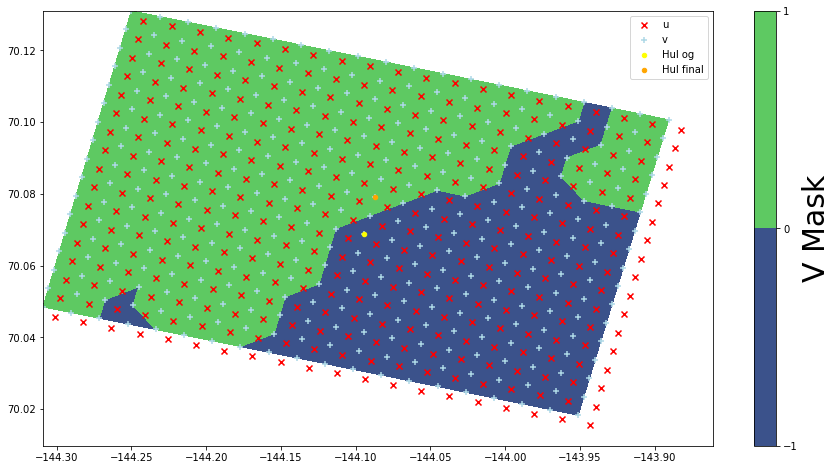

In [162]:
# NEW TO BE ON V AND NOT IN MASK

# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.mask_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='lightblue', marker='+', label='v')


# Hulahula
ax2.scatter(grid.lon_v[eta_hul_idx, xi_hul_idx].values, grid.lat_v[eta_hul_idx, xi_hul_idx].values, 
            marker='.', s=80, color='yellow', label='Hul og')

# Point 1 - u face
eta_hul_idx_test1 = 40
xi_hul_idx_test1 = 489

ax2.scatter(grid.lon_v[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            grid.lat_v[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            marker='.', s=80, color='orange', label='Hul final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [163]:
# Check that these spots are in the mask - ORIGINAL
# Point 1 - u
print(grid.mask_u[eta_hul_idx_test1,xi_hul_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
#eta_riv_arr[15] = eta_hul_idx_test1
#xi_riv_arr[15] = xi_hul_idx_test1

0.0


In [164]:
# Check that these spots are in the mask - NEW
# Point 1 - v
print(grid.mask_v[eta_hul_idx_test1,xi_hul_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[15] = eta_hul_idx_test1
xi_riv_arr[15] = xi_hul_idx_test1

1.0


In [165]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
#riv_dir_hul1 = 0 # OG 
riv_dir_hul1 = 1 # NEW

# Add this to the list 
riv_direction_arr[15] = riv_dir_hul1

In [166]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_hul1 = (river_data_hul['Discharge(m3/s)'][912:1037].values)/len_river_cells_hul

# Add this to the list 
riv_transport_arr[:,15] = Q_hul1

In [167]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_hul = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_hul = vshape_all[:, eta_hul_idx_test1, xi_hul_idx_test1]

# Add this to the array
riv_vshape_arr[:,15] = riv_vshape_hul

In [168]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_hul_tmp = river_data_hul['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_hul = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_hul = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_hul[:,i] = riv_temp_hul_tmp

# Add this to the array 
riv_temp_arr[:,:,15] = riv_temp_hul

In [169]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_hul = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,15] = riv_salt_hul

In [170]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_hul = 10 / Q_hul1 # when there is real data, may need one for each cell
# #riv_mud_01_hul = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_hul = 10 / Q_hul1 # when there is real data, may need one for each cell
# #riv_mud_02_hul = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_hul_tmp = calc_river_ssc_Anaktuvuk(Q_hul1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_hul_tmp = calc_river_ssc_Sag_DSS3(Q_hul1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_hul_tmp = calc_river_ssc_Sag_DSS2(Q_hul1)

# Convert output from mg/L to kg/m3
riv_mud_hul = riv_mud_hul_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_hul = riv_mud_hul/2
riv_mud_23_hul = riv_mud_hul/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,15] = riv_mud_01_hul

# mud 23
riv_mud_23_arr[:,15] = riv_mud_23_hul

In [171]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_hul = 0 / Q_hul1

# mud 02 
riv_mud_02_hul = 0 / Q_hul1

# mud 03
riv_mud_03_hul = 0 / Q_hul1

# mud 04
riv_mud_04_hul = 0 / Q_hul1

# mud 05
riv_mud_05_hul = 0 / Q_hul1

# mud 06
riv_mud_06_hul = 0 / Q_hul1

# mud 07
riv_mud_07_hul = 0 / Q_hul1

# mud 08
riv_mud_08_hul = 0 / Q_hul1

# mud 09
riv_mud_09_hul = 0 / Q_hul1

# mud 10
riv_mud_10_hul = 0 / Q_hul1

# mud 11
riv_mud_11_hul = 0 / Q_hul1

# mud 12
riv_mud_12_hul = 0 / Q_hul1

# mud 13
riv_mud_13_hul = 0 / Q_hul1

# mud 14
riv_mud_14_hul = 0 / Q_hul1

# mud 15
riv_mud_15_hul = 0 / Q_hul1

# mud 16
riv_mud_16_hul = 0 / Q_hul1

# mud 17
riv_mud_17_hul = 0 / Q_hul1

# mud 18
riv_mud_18_hul = 0 / Q_hul1

# mud 19
riv_mud_19_hul = 0 / Q_hul1

# mud 20
riv_mud_20_hul = 0 / Q_hul1

# mud 21
riv_mud_21_hul = 0 / Q_hul1

# mud 22
riv_mud_22_hul = 0 / Q_hul1

# mud 23
#riv_mud_23_hul = 0 / Q_hul1

# mud 24
riv_mud_24_hul = 0 / Q_hul1

# mud 25
#riv_mud_25_hul = 0 / Q_hul1

# mud 26
#riv_mud_26_hul = 0 / Q_hul1

# mud 27
#riv_mud_27_hul = 0 / Q_hul1

# mud 28
#riv_mud_28_hul = 0 / Q_hul1

# mud 29
#riv_mud_29_hul = 0 / Q_hul1

# mud 30
#riv_mud_30_hul = 0 / Q_hul1

# Save these to the arrays 
#riv_mud_01_arr[:,15] = riv_mud_01_hul

riv_mud_02_arr[:,15] = riv_mud_02_hul
riv_mud_03_arr[:,15] = riv_mud_03_hul
riv_mud_04_arr[:,15] = riv_mud_04_hul
riv_mud_05_arr[:,15] = riv_mud_05_hul
riv_mud_06_arr[:,15] = riv_mud_06_hul
riv_mud_07_arr[:,15] = riv_mud_07_hul
riv_mud_08_arr[:,15] = riv_mud_08_hul
riv_mud_09_arr[:,15] = riv_mud_09_hul
riv_mud_10_arr[:,15] = riv_mud_10_hul
riv_mud_11_arr[:,15] = riv_mud_11_hul
riv_mud_12_arr[:,15] = riv_mud_12_hul
riv_mud_13_arr[:,15] = riv_mud_13_hul
riv_mud_14_arr[:,15] = riv_mud_14_hul
riv_mud_15_arr[:,15] = riv_mud_15_hul
riv_mud_16_arr[:,15] = riv_mud_16_hul
riv_mud_17_arr[:,15] = riv_mud_17_hul
riv_mud_18_arr[:,15] = riv_mud_18_hul
riv_mud_19_arr[:,15] = riv_mud_19_hul
riv_mud_20_arr[:,15] = riv_mud_20_hul
riv_mud_21_arr[:,15] = riv_mud_21_hul
riv_mud_22_arr[:,15] = riv_mud_22_hul
#riv_mud_23_arr[:,15] = riv_mud_23_hul
riv_mud_24_arr[:,15] = riv_mud_24_hul
#riv_mud_25_arr[:,15] = riv_mud_25_hul
#riv_mud_26_arr[:,15] = riv_mud_26_hul
#riv_mud_27_arr[:,15] = riv_mud_27_hul
#riv_mud_28_arr[:,15] = riv_mud_28_hul
#riv_mud_29_arr[:,15] = riv_mud_29_hul
#riv_mud_30_arr[:,15] = riv_mud_30_hul

In [172]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_01_hul = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_02_hul = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_03_hul = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,15] = riv_sand_01_hul

# sand 02
riv_sand_02_arr[:,15] = riv_sand_02_hul

# sand 03
riv_sand_03_arr[:,15] = riv_sand_03_hul

In [173]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Hulahula
riv_id_hul = 9 #13

# Add this to the array
riv_id_arr[15] = riv_id_hul

In [174]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_hul = 3

# Add this to the array
riv_flag_arr[15] = riv_flag_hul

## Jago River 
Location: 70.1088, -143.2918  
Width: 921 m

In [175]:
# Jago River (70.1088, -143.2918), 921 m
# Set the number of cells it will take 
# 921 m / 750 m = 1.23 ~ 1 cells
len_river_cells_jag = 1

# Find it manually
eta_jag_idx = 58
xi_jag_idx = 527

# Needs to be on u or v point, depending what makes sense here
print('Jago Lat v: ', grid.lat_v[eta_jag_idx, xi_jag_idx].values)
print('Jago Lon v: ', grid.lon_v[eta_jag_idx, xi_jag_idx].values)

Jago Lat v:  70.10931742606864
Jago Lon v:  -143.3007382705922


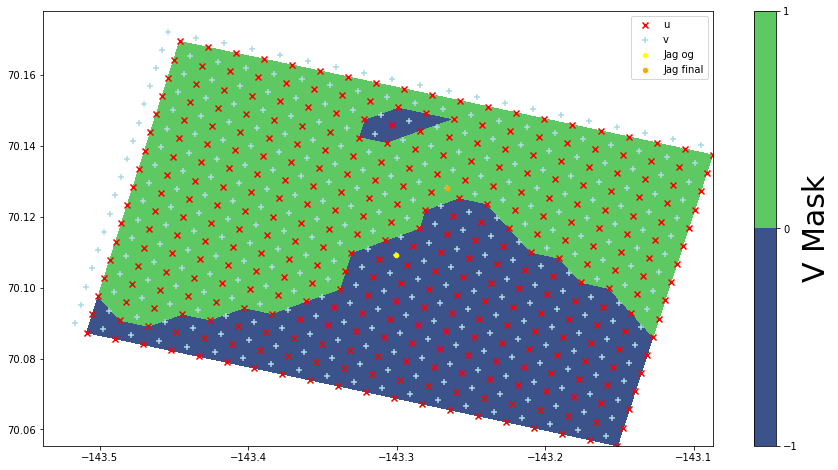

In [176]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
                    grid.lat_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
                    grid.mask_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
            grid.lat_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
            grid.lat_v[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values,
            color='lightblue', marker='+', label='v')


# Jago
ax2.scatter(grid.lon_v[eta_jag_idx, xi_jag_idx].values, grid.lat_v[eta_jag_idx, xi_jag_idx].values, 
            marker='.', s=80, color='yellow', label='Jag og')

# Point 1 - v face
eta_jag_idx_test1 = 62 #61
xi_jag_idx_test1 = 528

ax2.scatter(grid.lon_v[eta_jag_idx_test1, xi_jag_idx_test1].values, 
            grid.lat_v[eta_jag_idx_test1, xi_jag_idx_test1].values, 
            marker='.', s=80, color='orange', label='Jag final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [177]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_jag_idx_test1,xi_jag_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[16] = eta_jag_idx_test1
xi_riv_arr[16] = xi_jag_idx_test1

1.0


In [178]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_jag1 = 1

# Add this to the list 
riv_direction_arr[16] = riv_dir_jag1

In [179]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Use Blaskey data
Q_jag1 = (river_data_jag['Discharge(m3/s)'][912:1037].values)/len_river_cells_jag

# Add this to the list 
riv_transport_arr[:,16] = Q_jag1

In [180]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_jag = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_jag = vshape_all[:, eta_jag_idx_test1, xi_jag_idx_test1]

# Add this to the array
riv_vshape_arr[:,16] = riv_vshape_jag

In [181]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# Read in river temperature from Blaskey data
riv_temp_jag_tmp = river_data_jag['WaterTemp(C)'][912:1037].values

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_jag = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_jag = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_jag[:,i] = riv_temp_jag_tmp

# Add this to the array 
riv_temp_arr[:,:,16] = riv_temp_jag

In [182]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_jag = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,16] = riv_salt_jag

In [183]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_jag = 10 / Q_jag1 # when there is real data, may need one for each cell
# #riv_mud_01_jag = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_jag = 10 / Q_jag1 # when there is real data, may need one for each cell
# #riv_mud_02_jag = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
#riv_mud_jag_tmp = calc_river_ssc_Anaktuvuk(Q_jag1)
# --- Toniolo et al. 2024 version DSS3 --- 
riv_mud_jag_tmp = calc_river_ssc_Sag_DSS3(Q_jag1)
# --- Toniolo et al. 2024 version DSS2 --- 
#riv_mud_jag_tmp = calc_river_ssc_Sag_DSS2(Q_jag1)

# Convert output from mg/L to kg/m3
riv_mud_jag = riv_mud_jag_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_jag = riv_mud_jag/2
riv_mud_24_jag = riv_mud_jag/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,16] = riv_mud_01_jag

# mud 24
riv_mud_24_arr[:,16] = riv_mud_24_jag

In [184]:
# Set all the other mud classes to 0 for this river 

# mud 01
#riv_mud_01_jag = 0 / Q_jag1

# mud 02 
riv_mud_02_jag = 0 / Q_jag1

# mud 03
riv_mud_03_jag = 0 / Q_jag1

# mud 04
riv_mud_04_jag = 0 / Q_jag1

# mud 05
riv_mud_05_jag = 0 / Q_jag1

# mud 06
riv_mud_06_jag = 0 / Q_jag1

# mud 07
riv_mud_07_jag = 0 / Q_jag1

# mud 08
riv_mud_08_jag = 0 / Q_jag1

# mud 09
riv_mud_09_jag = 0 / Q_jag1

# mud 10
riv_mud_10_jag = 0 / Q_jag1

# mud 11
riv_mud_11_jag = 0 / Q_jag1

# mud 12
riv_mud_12_jag = 0 / Q_jag1

# mud 13
riv_mud_13_jag = 0 / Q_jag1

# mud 14
riv_mud_14_jag = 0 / Q_jag1

# mud 15
riv_mud_15_jag = 0 / Q_jag1

# mud 16
riv_mud_16_jag = 0 / Q_jag1

# mud 17
riv_mud_17_jag = 0 / Q_jag1

# mud 18
riv_mud_18_jag = 0 / Q_jag1

# mud 19
riv_mud_19_jag = 0 / Q_jag1

# mud 20
riv_mud_20_jag = 0 / Q_jag1

# mud 21
riv_mud_21_jag = 0 / Q_jag1

# mud 22
riv_mud_22_jag = 0 / Q_jag1

# mud 23
riv_mud_23_jag = 0 / Q_jag1

# mud 24
#riv_mud_24_jag = 0 / Q_jag1

# mud 25
#riv_mud_25_jag = 0 / Q_jag1

# mud 26
#riv_mud_26_jag = 0 / Q_jag1

# mud 27
#riv_mud_27_jag = 0 / Q_jag1

# mud 28
#riv_mud_28_jag = 0 / Q_jag1

# mud 29
#riv_mud_29_jag = 0 / Q_jag1

# mud 30
#riv_mud_30_jag = 0 / Q_jag1

# Save these to the arrays 
#riv_mud_01_arr[:,16] = riv_mud_01_jag

riv_mud_02_arr[:,16] = riv_mud_02_jag
riv_mud_03_arr[:,16] = riv_mud_03_jag
riv_mud_04_arr[:,16] = riv_mud_04_jag
riv_mud_05_arr[:,16] = riv_mud_05_jag
riv_mud_06_arr[:,16] = riv_mud_06_jag
riv_mud_07_arr[:,16] = riv_mud_07_jag
riv_mud_08_arr[:,16] = riv_mud_08_jag
riv_mud_09_arr[:,16] = riv_mud_09_jag
riv_mud_10_arr[:,16] = riv_mud_10_jag
riv_mud_11_arr[:,16] = riv_mud_11_jag
riv_mud_12_arr[:,16] = riv_mud_12_jag
riv_mud_13_arr[:,16] = riv_mud_13_jag
riv_mud_14_arr[:,16] = riv_mud_14_jag
riv_mud_15_arr[:,16] = riv_mud_15_jag
riv_mud_16_arr[:,16] = riv_mud_16_jag
riv_mud_17_arr[:,16] = riv_mud_17_jag
riv_mud_18_arr[:,16] = riv_mud_18_jag
riv_mud_19_arr[:,16] = riv_mud_19_jag
riv_mud_20_arr[:,16] = riv_mud_20_jag
riv_mud_21_arr[:,16] = riv_mud_21_jag
riv_mud_22_arr[:,16] = riv_mud_22_jag
riv_mud_23_arr[:,16] = riv_mud_23_jag
#riv_mud_24_arr[:,16] = riv_mud_24_jag
#riv_mud_25_arr[:,16] = riv_mud_25_jag
#riv_mud_26_arr[:,16] = riv_mud_26_jag
#riv_mud_27_arr[:,16] = riv_mud_27_jag
#riv_mud_28_arr[:,16] = riv_mud_28_jag
#riv_mud_29_arr[:,16] = riv_mud_29_jag
#riv_mud_30_arr[:,16] = riv_mud_30_jag

In [185]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Verison ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_01_jag = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_02_jag = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_03_jag = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,16] = riv_sand_01_jag

# sand 02
riv_sand_02_arr[:,16] = riv_sand_02_jag

# sand 03
riv_sand_03_arr[:,16] = riv_sand_03_jag

In [186]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Jago
riv_id_jag = 10 #14

# Add this to the array
riv_id_arr[16] = riv_id_jag

In [187]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_jag = 3

# Add this to the array
riv_flag_arr[16] = riv_flag_jag

## Siksik River 
Location: 69.9501, -142.4938  
Width: 176.5 m  
This river has been commented out since it is so small and not in the Blaskey data.

In [188]:
# # Siksik River (69.9501, -142.4938), 176.5 m
# # Set the number of cells it will take 
# # 176.5 m / 750 m = ~ 1 cells
# len_river_cells_sik = 1

# # Find it manually
# eta_sik_idx = 43
# xi_sik_idx = 573

# # Needs to be on u or v point, depending what makes sense here
# print('Siksik Lat u: ', grid.lat_u[eta_sik_idx, xi_sik_idx].values)
# print('Siksik Lon u: ', grid.lon_u[eta_sik_idx, xi_sik_idx].values)

In [189]:
# # Make a plot that is a scatter plot of u and v points
# # Plot this point on the grid
# # Zoom in to see if we are in the mask
# fig2, ax2 = plt.subplots(figsize=(15,8))
# # Plot the mask
# cs2 = ax2.contourf(grid.lon_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
#                     grid.lat_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
#                     grid.mask_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, lev1)

# # Plot the u points
# ax2.scatter(grid.lon_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
#             grid.lat_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values,
#             color='red', marker='x', label='u')

# # Plot the v points
# ax2.scatter(grid.lon_v[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
#             grid.lat_v[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values,
#             color='lightblue', marker='+', label='v')


# # Siksik
# ax2.scatter(grid.lon_u[eta_sik_idx, xi_sik_idx].values, grid.lat_u[eta_sik_idx, xi_sik_idx].values, 
#             marker='.', s=80, color='yellow', label='Sik og')

# # Point 1 - v face
# eta_sik_idx_test1 = 46
# xi_sik_idx_test1 = 574 #573

# ax2.scatter(grid.lon_u[eta_sik_idx_test1, xi_sik_idx_test1].values, 
#             grid.lat_u[eta_sik_idx_test1, xi_sik_idx_test1].values, 
#             marker='.', s=80, color='orange', label='Sik final')

# ax2.legend()

# cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [190]:
# # Check that these spots are in the mask
# # Point 1 - u
# print(grid.mask_u[eta_sik_idx_test1,xi_sik_idx_test1].values)
# # If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
# eta_riv_arr[19] = eta_sik_idx_test1
# xi_riv_arr[19] = xi_sik_idx_test1

In [191]:
# # Set the river_direction
# # "river runoff grid-cell face flag"
# # where river_direction:flag_values = "0, 1, 2" 
# # river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# # Set this for each of the 5 points
# riv_dir_sik1 = 0

# # Add this to the list 
# riv_direction_arr[19] = riv_dir_sik1

In [192]:
# # Set river_transport which is the direction of the flow across the u or v face
# # This is also where we put "river runoff vertically integrated mass transport"
# # river_transport(river_time, river)

# # Use Blaskey data
# Q_sik1 = (river_data_sik['Discharge(m3/s)'][912:1037].values)/len_river_cells_sik

# # Add this to the list 
# riv_transport_arr[:,19] = Q_sik1

In [193]:
# # Set river_vshape
# # "sets the fractional distribution of the river_transport 
# # among the vertical cells and must sum to 1.0 over the vertical"
# # "If the river source is in shallow water several grid cells up a 
# # river tributary then a simple uniform vertical distribution 
# # (all river_Vshape values = 1/s_rho) usually works well"

# # Do uniform distribution over all depths 
# #riv_vshape_sik = np.full((s_rho_len), 1/s_rho_len)

# # Read in the vshape for this cell
# # Use the indices from above - these are u/v indices but v_shape 
# # is n terms of rho indices but hopefully they are close enough 
# # that it doesn't matter too much but keep note of this 
# riv_vshape_sik = vshape_all[:, eta_sik_idx_test1, xi_sik_idx_test1]

# # Add this to the array
# riv_vshape_arr[:,19] = riv_vshape_sik

In [194]:
# # Set river runoff potential temperature 
# # river_temp(river_time, s_rho, river) 
# # river_temp:long_name = "river runoff potential temperature" 
# # river_temp:units = "Celsius" 
# # river_temp:time = "river_time" 

# # Read in river temperature from Blaskey data
# riv_temp_sik_tmp = river_data_sik['WaterTemp(C)'][912:1037].values

# # This looks like it can vary vertically and can be a timeseries 
# #riv_temp_sik = np.full((time_tmp_len, s_rho_len), 11)
# # Make this the same in each layer 
# riv_temp_sik = np.empty((time_tmp_len, s_rho_len))
# for i in range(s_rho_len):
#     riv_temp_sik[:,i] = riv_temp_sik_tmp

# # Add this to the array 
# riv_temp_arr[:,:,19] = riv_temp_sik

In [195]:
# # Set the river runoff salinity
# # river_salt(river_time, s_rho, river) 
# # river_salt:long_name = "river runoff salinity" 
# # river_salt:time = "river_time"
# # units: PSS (nondimensional)

# # Just like temp, this can vary vertically and over time
# riv_salt_sik = np.full((time_tmp_len, s_rho_len), 0)

# # Add this to the array
# riv_salt_arr[:,:,19] = riv_salt_sik

In [196]:
# # Set the river mud
# # 'river_mud_'                                       ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # # for all rivers and all sediment classes
# # # mud class 01
# # riv_mud_01_sik = 10 / Q_sik1 # when there is real data, may need one for each cell
# # #riv_mud_01_sik = np.full((time_tmp_len), 0.00001)

# # # mud class 02
# # riv_mud_02_sik = 10 / Q_sik1 # when there is real data, may need one for each cell
# # #riv_mud_02_sik = np.full((time_tmp_len), 0.00001)

# # --- Lamb and Toniolo 2016 Version ---
# riv_mud_sik_tmp = calc_river_ssc_Anaktuvuk(Q_sik1)
# # --- Toniolo et al. 2024 version DSS3 --- 
# #riv_mud_sik_tmp = calc_river_ssc_Sag_DSS3(Q_sik1)
# # --- Toniolo et al. 2024 version DSS2 --- 
# #riv_mud_sik_tmp = calc_river_ssc_Sag_DSS2(Q_sik1)

# # Convert output from mg/L to kg/m3
# riv_mud_sik = riv_mud_sik_tmp/1000

# # Divide the total river sediment discharge by two 
# # so that half belongs to each mud class
# riv_mud_01_sik = riv_mud_sik/2
# riv_mud_27_sik = riv_mud_sik/2

# # Add these to the arrays (can definitely shorten this but oh well)
# # mud 01
# riv_mud_01_arr[:,19] = riv_mud_01_sik

# # mud 27
# riv_mud_27_arr[:,19] = riv_mud_27_sik

In [197]:
# # Set all the other mud classes to 0 for this river 

# # mud 01
# #riv_mud_01_sik = 0 / Q_sik1

# # mud 02 
# riv_mud_02_sik = 0 / Q_sik1

# # mud 03
# riv_mud_03_sik = 0 / Q_sik1

# # mud 04
# riv_mud_04_sik = 0 / Q_sik1

# # mud 05
# riv_mud_05_sik = 0 / Q_sik1

# # mud 06
# riv_mud_06_sik = 0 / Q_sik1

# # mud 07
# riv_mud_07_sik = 0 / Q_sik1

# # mud 08
# riv_mud_08_sik = 0 / Q_sik1

# # mud 09
# riv_mud_09_sik = 0 / Q_sik1

# # mud 10
# riv_mud_10_sik = 0 / Q_sik1

# # mud 11
# riv_mud_11_sik = 0 / Q_sik1

# # mud 12
# riv_mud_12_sik = 0 / Q_sik1

# # mud 13
# riv_mud_13_sik = 0 / Q_sik1

# # mud 14
# riv_mud_14_sik = 0 / Q_sik1

# # mud 15
# riv_mud_15_sik = 0 / Q_sik1

# # mud 16
# riv_mud_16_sik = 0 / Q_sik1

# # mud 17
# riv_mud_17_sik = 0 / Q_sik1

# # mud 18
# riv_mud_18_sik = 0 / Q_sik1

# # mud 19
# riv_mud_19_sik = 0 / Q_sik1

# # mud 20
# riv_mud_20_sik = 0 / Q_sik1

# # mud 21
# riv_mud_21_sik = 0 / Q_sik1

# # mud 22
# riv_mud_22_sik = 0 / Q_sik1

# # mud 23
# riv_mud_23_sik = 0 / Q_sik1

# # mud 24
# riv_mud_24_sik = 0 / Q_sik1

# # mud 25
# riv_mud_25_sik = 0 / Q_sik1

# # mud 26
# riv_mud_26_sik = 0 / Q_sik1

# # mud 27
# #riv_mud_27_sik = 0 / Q_sik1

# # mud 28
# #riv_mud_28_sik = 0 / Q_sik1

# # mud 29
# #riv_mud_29_sik = 0 / Q_sik1

# # mud 30
# #riv_mud_30_sik = 0 / Q_sik1

# # Save these to the arrays 
# #riv_mud_01_arr[:,19] = riv_mud_01_sik

# riv_mud_02_arr[:,19] = riv_mud_02_sik
# riv_mud_03_arr[:,19] = riv_mud_03_sik
# riv_mud_04_arr[:,19] = riv_mud_04_sik
# riv_mud_05_arr[:,19] = riv_mud_05_sik
# riv_mud_06_arr[:,19] = riv_mud_06_sik
# riv_mud_07_arr[:,19] = riv_mud_07_sik
# riv_mud_08_arr[:,19] = riv_mud_08_sik
# riv_mud_09_arr[:,19] = riv_mud_09_sik
# riv_mud_10_arr[:,19] = riv_mud_10_sik
# riv_mud_11_arr[:,19] = riv_mud_11_sik
# riv_mud_12_arr[:,19] = riv_mud_12_sik
# riv_mud_13_arr[:,19] = riv_mud_13_sik
# riv_mud_14_arr[:,19] = riv_mud_14_sik
# riv_mud_15_arr[:,19] = riv_mud_15_sik
# riv_mud_16_arr[:,19] = riv_mud_16_sik
# riv_mud_17_arr[:,19] = riv_mud_17_sik
# riv_mud_18_arr[:,19] = riv_mud_18_sik
# riv_mud_19_arr[:,19] = riv_mud_19_sik
# riv_mud_20_arr[:,19] = riv_mud_20_sik
# riv_mud_21_arr[:,19] = riv_mud_21_sik
# riv_mud_22_arr[:,19] = riv_mud_22_sik
# riv_mud_23_arr[:,19] = riv_mud_23_sik
# riv_mud_24_arr[:,19] = riv_mud_24_sik
# riv_mud_25_arr[:,19] = riv_mud_25_sik
# riv_mud_26_arr[:,19] = riv_mud_26_sik
# #riv_mud_27_arr[:,19] = riv_mud_27_sik
# #riv_mud_28_arr[:,19] = riv_mud_28_sik
# #riv_mud_29_arr[:,19] = riv_mud_29_sik
# #riv_mud_30_arr[:,19] = riv_mud_30_sik

In [198]:
# # Set the river sand
# # 'river_sand_'                                      ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # *Set all of these to 0 since sand might be too big to be carried by the river*

# # sand class 01
# riv_sand_01_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
# #riv_sand_01_sik = np.full((time_tmp_len), 0.0001)

# # sand class 02
# riv_sand_02_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
# #riv_sand_02_sik = np.full((time_tmp_len), 0.0001)

# # sand class 03
# riv_sand_03_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
# #riv_sand_03_sik = np.full((time_tmp_len), 0.0)

# # Add this to the array
# # sand 01 
# riv_sand_01_arr[:,19] = riv_sand_01_sik

# # sand 02
# riv_sand_02_arr[:,19] = riv_sand_02_sik

# # sand 03
# riv_sand_03_arr[:,19] = riv_sand_03_sik

In [199]:
# # Set the river id number
# # This number will match the one in the info for the netcdf
# # Siksik
# riv_id_sik = 13 #15

# # Add this to the array
# riv_id_arr[19] = riv_id_sik

In [200]:
# # Set the river flag ('river runoff tracer flag')
# # rdir.flag_values = '0, 1, 2, 3'
# # rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# # only salinity is on, both temperature and salinity are on'
# riv_flag_sik = 3

# # Add this to the array
# riv_flag_arr[19] = riv_flag_sik

## Make the NetCDF

In [201]:
# Make the netcdf
# Name of the netcdf file. This is up to you.
file_name = '/Users/brun1463/Desktop/Research_Lab/Beaufort_Shelf_Rivers_proj_002/Model_Input/Rivers/river_forcing_file_beaufort_shelf_10rivs_13seabed_blaskey_data_sagDSS3_rating_001.nc'

# Create and write to a netcdf file
nc = Dataset(file_name, 'w', format='NETCDF4')

# Create a variable for grid mapping
gridmap_varname = 'grid_mapping'

# Global attributes-- the dictionary.
global_defaults = dict(rivers      = '(1) Kalikpik River, (2) Colville River, (3) Sagavanirktok, (4) Fish Creek, (5) Kuparik' +
                       ' (6) Staines, (7) Canning, (8) Katakturuk, (9) Hulahula, (10) Jago',
                       title       = 'River Discharge Interpolated to Kaktovik Shelf Grid', 
                       type        = 'ROMS river input file',
                       Institution = 'University of Colorado Boulder, Dept. of Atmospheric and Oceanic Sciences',
                       Source      = 'Artifical (for now)',
                       date        =  str(datetime.today()))

# Create dictionary for model
d = {}
d = global_defaults

# print d
for att, value in d.items():
    setattr(nc, att, value)

In [202]:
# Create the dimensions
nc.createDimension('river_time', None)
nc.createDimension('s_rho',  s_rho_len)
nc.createDimension('river',  len_river_cells) #is this right?

<class 'netCDF4._netCDF4.Dimension'>: name = 'river', size = 17

In [203]:
#nc.close()
#print(np.shape(riv_transport_list))

In [204]:
# Create the variables
# River_time
river_time = nc.createVariable('river_time', 'd', ('river_time'), zlib=True)
river_time.long_name = 'river runoff time'
river_time.units = 'seconds since 2000-01-01 00:00:00'
river_time[:] = time_tmp[:]

# River
river = nc.createVariable('river', 'd', ('river'), zlib=True)
river.long_name = 'river runoff identification number'
river[:] = riv_id_arr[:]

# River_direction
rdir = nc.createVariable('river_direction', 'd', ('river'), zlib=True)
rdir.long_name = 'river runoff grid-cell face flag'
rdir.flag_values = '0, 1, 2'
rdir.flag_meanings = 'flow across u-face, flow across v-face, flow across w-face'
rdir[:] = riv_direction_arr[:]
#rdir[:] = np.full(num_river_cells, river_dir)


# Position of each river cell in the xi-direction
xpos = nc.createVariable('river_Xposition', 'd', ('river'), zlib=True)
xpos.long_name = 'river XI-position'
xpos.LuvSrc = 'T'
xpos.LuvSrc_meaning = 'i-index grid-cell of u- or v-face source/sink'
xpos.LwSrc_meaning = 'i-index grid-cell of w-face source/sink'
xpos[:] = xi_riv_arr[:]
#xpos[:] = river_cells_xi[:]

# Position of each river cell in the eta-direction
epos = nc.createVariable('river_Eposition', 'd', ('river'), zlib=True)
epos.long_name = 'river ETA-position'
epos.LuvSrc_True_meaning = 'j-index grid-cell of u- or v-face source/sink'
epos.LwSrc_True_meaning = 'j-index grid-cell of w-face source/sink'
epos[:] = eta_riv_arr[:]
#epos[:] = river_cells_eta[:]

# River_Vshape
vshape = nc.createVariable('river_Vshape', 'd', ('s_rho', 'river'), zlib=True)
vshape.long_name = 'river runoff mass transport vertical profile'
vshape.requires = 'must sum to 1 over s_rho coordinate'
vshape[:] = riv_vshape_arr[:,:]
#vshape[:,:] = Vshape_frac[:,:]

# River_transport
transport = nc.createVariable('river_transport', 'd', ('river_time', 'river'), zlib=True)
transport.long_name = 'river runoff vertically integrated mass transport'
transport.units = 'meter3 second-1'
transport.positive = 'LuvSrc=T flow in positive u,v direction, LwSrc=T flow into grid-cell'
transport.negative = 'LuvSrc=T flow in negative u,v direction, LwSrc=T flow out of grid-cell'
transport.time = 'river_time'
transport[:,:] = riv_transport_arr[:,:]
#transport[:,:] = Q_roms[:,:]

# River_temp
temp = nc.createVariable('river_temp', 'd', ('river_time', 's_rho', 'river'), zlib=True)
temp.long_name = 'river runoff potential temperature'
temp.units = 'Celsius'
temp.time = 'river_time'
temp[:,:,:] = riv_temp_arr[:,:,:]
#temp[:,:,:] = river_temp_roms[:,:,:]

# River_salt
salt = nc.createVariable('river_salt', 'd', ('river_time', 's_rho', 'river'), zlib=True)
salt.long_name = 'river runoff salinity'
salt.time = 'river_time'
salt[:,:,:] = riv_salt_arr[:,:,:]
#salt[:,:,:] = salt_roms[:,:,:]

# SEABED 
# River mud 01
mud_01 = nc.createVariable('river_mud_01', 'd', ('river_time', 'river'), zlib=True)
mud_01.long_name = 'river runoff suspended sediment concentration'
mud_01.time = 'river_time'
mud_01.units = 'kilogram meter-3'
mud_01[:,:] = riv_mud_01_arr[:,:]

# River mud 02
mud_02 = nc.createVariable('river_mud_02', 'd', ('river_time', 'river'), zlib=True)
mud_02.long_name = 'river runoff suspended sediment concentration'
mud_02.time = 'river_time'
mud_02.units = 'kilogram meter-3'
mud_02[:,:] = riv_mud_02_arr[:,:]

# River sand 01
sand_01 = nc.createVariable('river_sand_01', 'd', ('river_time', 'river'), zlib=True)
sand_01.long_name = 'river runoff suspended sediment concentration'
sand_01.time = 'river_time'
sand_01.units = 'kilogram meter-3'
sand_01[:,:] = riv_sand_01_arr[:,:]

# River sand 02
sand_02 = nc.createVariable('river_sand_02', 'd', ('river_time', 'river'), zlib=True)
sand_02.long_name = 'river runoff suspended sediment concentration'
sand_02.time = 'river_time'
sand_02.units = 'kilogram meter-3'
sand_02[:,:] = riv_sand_02_arr[:,:]

# River sand 03
sand_03 = nc.createVariable('river_sand_03', 'd', ('river_time', 'river'), zlib=True)
sand_03.long_name = 'river runoff suspended sediment concentration'
sand_03.time = 'river_time'
sand_03.units = 'kilogram meter-3'
sand_03[:,:] = riv_sand_03_arr[:,:]

# RIVERS

# River mud 03
mud_03 = nc.createVariable('river_mud_03', 'd', ('river_time', 'river'), zlib=True)
mud_03.long_name = 'river runoff suspended sediment concentration'
mud_03.time = 'river_time'
mud_03.units = 'kilogram meter-3'
mud_03[:,:] = riv_mud_03_arr[:,:]

# River mud 04
mud_04 = nc.createVariable('river_mud_04', 'd', ('river_time', 'river'), zlib=True)
mud_04.long_name = 'river runoff suspended sediment concentration'
mud_04.time = 'river_time'
mud_04.units = 'kilogram meter-3'
mud_04[:,:] = riv_mud_04_arr[:,:]

# River mud 05
mud_05 = nc.createVariable('river_mud_05', 'd', ('river_time', 'river'), zlib=True)
mud_05.long_name = 'river runoff suspended sediment concentration'
mud_05.time = 'river_time'
mud_05.units = 'kilogram meter-3'
mud_05[:,:] = riv_mud_05_arr[:,:]

# River mud 06
mud_06 = nc.createVariable('river_mud_06', 'd', ('river_time', 'river'), zlib=True)
mud_06.long_name = 'river runoff suspended sediment concentration'
mud_06.time = 'river_time'
mud_06.units = 'kilogram meter-3'
mud_06[:,:] = riv_mud_06_arr[:,:]

# River mud 07
mud_07 = nc.createVariable('river_mud_07', 'd', ('river_time', 'river'), zlib=True)
mud_07.long_name = 'river runoff suspended sediment concentration'
mud_07.time = 'river_time'
mud_07.units = 'kilogram meter-3'
mud_07[:,:] = riv_mud_07_arr[:,:]

# River mud 08
mud_08 = nc.createVariable('river_mud_08', 'd', ('river_time', 'river'), zlib=True)
mud_08.long_name = 'river runoff suspended sediment concentration'
mud_08.time = 'river_time'
mud_08.units = 'kilogram meter-3'
mud_08[:,:] = riv_mud_08_arr[:,:]

# River mud 09
mud_09 = nc.createVariable('river_mud_09', 'd', ('river_time', 'river'), zlib=True)
mud_09.long_name = 'river runoff suspended sediment concentration'
mud_09.time = 'river_time'
mud_09.units = 'kilogram meter-3'
mud_09[:,:] = riv_mud_09_arr[:,:]

# River mud 10
mud_10 = nc.createVariable('river_mud_10', 'd', ('river_time', 'river'), zlib=True)
mud_10.long_name = 'river runoff suspended sediment concentration'
mud_10.time = 'river_time'
mud_10.units = 'kilogram meter-3'
mud_10[:,:] = riv_mud_10_arr[:,:]

# River mud 11
mud_11 = nc.createVariable('river_mud_11', 'd', ('river_time', 'river'), zlib=True)
mud_11.long_name = 'river runoff suspended sediment concentration'
mud_11.time = 'river_time'
mud_11.units = 'kilogram meter-3'
mud_11[:,:] = riv_mud_11_arr[:,:]

# River mud 12
mud_12 = nc.createVariable('river_mud_12', 'd', ('river_time', 'river'), zlib=True)
mud_12.long_name = 'river runoff suspended sediment concentration'
mud_12.time = 'river_time'
mud_12.units = 'kilogram meter-3'
mud_12[:,:] = riv_mud_12_arr[:,:]

# River mud 13
mud_13 = nc.createVariable('river_mud_13', 'd', ('river_time', 'river'), zlib=True)
mud_13.long_name = 'river runoff suspended sediment concentration'
mud_13.time = 'river_time'
mud_13.units = 'kilogram meter-3'
mud_13[:,:] = riv_mud_13_arr[:,:]

# River mud 14
mud_14 = nc.createVariable('river_mud_14', 'd', ('river_time', 'river'), zlib=True)
mud_14.long_name = 'river runoff suspended sediment concentration'
mud_14.time = 'river_time'
mud_14.units = 'kilogram meter-3'
mud_14[:,:] = riv_mud_14_arr[:,:]

# River mud 15
mud_15 = nc.createVariable('river_mud_15', 'd', ('river_time', 'river'), zlib=True)
mud_15.long_name = 'river runoff suspended sediment concentration'
mud_15.time = 'river_time'
mud_15.units = 'kilogram meter-3'
mud_15[:,:] = riv_mud_15_arr[:,:]

# River mud 16
mud_16 = nc.createVariable('river_mud_16', 'd', ('river_time', 'river'), zlib=True)
mud_16.long_name = 'river runoff suspended sediment concentration'
mud_16.time = 'river_time'
mud_16.units = 'kilogram meter-3'
mud_16[:,:] = riv_mud_16_arr[:,:]

# River mud 17
mud_17 = nc.createVariable('river_mud_17', 'd', ('river_time', 'river'), zlib=True)
mud_17.long_name = 'river runoff suspended sediment concentration'
mud_17.time = 'river_time'
mud_17.units = 'kilogram meter-3'
mud_17[:,:] = riv_mud_17_arr[:,:]

# River mud 18
mud_18 = nc.createVariable('river_mud_18', 'd', ('river_time', 'river'), zlib=True)
mud_18.long_name = 'river runoff suspended sediment concentration'
mud_18.time = 'river_time'
mud_18.units = 'kilogram meter-3'
mud_18[:,:] = riv_mud_18_arr[:,:]

# River mud 19
mud_19 = nc.createVariable('river_mud_19', 'd', ('river_time', 'river'), zlib=True)
mud_19.long_name = 'river runoff suspended sediment concentration'
mud_19.time = 'river_time'
mud_19.units = 'kilogram meter-3'
mud_19[:,:] = riv_mud_19_arr[:,:]

# River mud 20
mud_20 = nc.createVariable('river_mud_20', 'd', ('river_time', 'river'), zlib=True)
mud_20.long_name = 'river runoff suspended sediment concentration'
mud_20.time = 'river_time'
mud_20.units = 'kilogram meter-3'
mud_20[:,:] = riv_mud_20_arr[:,:]

# River mud 21
mud_21 = nc.createVariable('river_mud_21', 'd', ('river_time', 'river'), zlib=True)
mud_21.long_name = 'river runoff suspended sediment concentration'
mud_21.time = 'river_time'
mud_21.units = 'kilogram meter-3'
mud_21[:,:] = riv_mud_21_arr[:,:]

# River mud 22
mud_22 = nc.createVariable('river_mud_22', 'd', ('river_time', 'river'), zlib=True)
mud_22.long_name = 'river runoff suspended sediment concentration'
mud_22.time = 'river_time'
mud_22.units = 'kilogram meter-3'
mud_22[:,:] = riv_mud_22_arr[:,:]

# River mud 23
mud_23 = nc.createVariable('river_mud_23', 'd', ('river_time', 'river'), zlib=True)
mud_23.long_name = 'river runoff suspended sediment concentration'
mud_23.time = 'river_time'
mud_23.units = 'kilogram meter-3'
mud_23[:,:] = riv_mud_23_arr[:,:]

# River mud 24
mud_24 = nc.createVariable('river_mud_24', 'd', ('river_time', 'river'), zlib=True)
mud_24.long_name = 'river runoff suspended sediment concentration'
mud_24.time = 'river_time'
mud_24.units = 'kilogram meter-3'
mud_24[:,:] = riv_mud_24_arr[:,:]

# # River mud 25
# mud_25 = nc.createVariable('river_mud_25', 'd', ('river_time', 'river'), zlib=True)
# mud_25.long_name = 'river runoff suspended sediment concentration'
# mud_25.time = 'river_time'
# mud_25.units = 'kilogram meter-3'
# mud_25[:,:] = riv_mud_25_arr[:,:]

# # River mud 26
# mud_26 = nc.createVariable('river_mud_26', 'd', ('river_time', 'river'), zlib=True)
# mud_26.long_name = 'river runoff suspended sediment concentration'
# mud_26.time = 'river_time'
# mud_26.units = 'kilogram meter-3'
# mud_26[:,:] = riv_mud_26_arr[:,:]

# # River mud 27
# mud_27 = nc.createVariable('river_mud_27', 'd', ('river_time', 'river'), zlib=True)
# mud_27.long_name = 'river runoff suspended sediment concentration'
# mud_27.time = 'river_time'
# mud_27.units = 'kilogram meter-3'
# mud_27[:,:] = riv_mud_27_arr[:,:]

# # River mud 28
# mud_28 = nc.createVariable('river_mud_28', 'd', ('river_time', 'river'), zlib=True)
# mud_28.long_name = 'river runoff suspended sediment concentration'
# mud_28.time = 'river_time'
# mud_28.units = 'kilogram meter-3'
# mud_28[:,:] = riv_mud_28_arr[:,:]

# # River mud 29
# mud_29 = nc.createVariable('river_mud_29', 'd', ('river_time', 'river'), zlib=True)
# mud_29.long_name = 'river runoff suspended sediment concentration'
# mud_29.time = 'river_time'
# mud_29.units = 'kilogram meter-3'
# mud_29[:,:] = riv_mud_29_arr[:,:]

# # River mud 30
# mud_30 = nc.createVariable('river_mud_30', 'd', ('river_time', 'river'), zlib=True)
# mud_30.long_name = 'river runoff suspended sediment concentration'
# mud_30.time = 'river_time'
# mud_30.units = 'kilogram meter-3'
# mud_30[:,:] = riv_mud_30_arr[:,:]

# River_flag
flag = nc.createVariable('river_flag', 'd', ('river'), zlib=True)
flag.long_name = 'river runoff tracer flag'
flag.flag_values = '0, 1, 2, 3'
flag.flag_meanings = 'all tracers are off, only temperature is on, only salinity is on, both temperature and salinity are on'
flag[:] = riv_flag_arr[:]
#flag[:] = np.full(num_river_cells, 0)

nc.close()
print('done')

done


In [205]:
#nc.close()